# YouTube Videos Analysis
Uncovering the Secrets of YouTube Trending Videos

The mission is to explore [the YouTube trending videos dataset](https://www.kaggle.com/datasets/datasnaek/youtube-new/) and uncover the key factors behind viral content. Through exploratory data analysis (EDA) and data visualization, we will analyze engagement patterns, trends, and content characteristics. However, this is not just about answering a set of predefined questions—we need to craft your own data-driven story and develop meaningful insights
based on it.

## Reading Data & Preprocessing

In [1]:
import kagglehub
import pandas as pd
import json
import warnings
warnings.filterwarnings("ignore")

# Download the latest version
path = kagglehub.dataset_download("datasnaek/youtube-new")

CA_df = pd.read_csv(path + "/CAvideos.csv")
with open(path + "/CA_category_id.json", "r") as f:
    CA_category = json.load(f)

DE_df = pd.read_csv(path + "/DEvideos.csv")
with open(path + "/DE_category_id.json", "r") as f:
    DE_category = json.load(f)

FR_df = pd.read_csv(path + "/FRvideos.csv")
with open(path + "/FR_category_id.json", "r") as f:
    FR_category = json.load(f)

GB_df = pd.read_csv(path + "/GBvideos.csv")
with open(path + "/GB_category_id.json", "r") as f:
    GB_category = json.load(f)

IN_df = pd.read_csv(path + "/INvideos.csv")
with open(path + "/IN_category_id.json", "r") as f:
    IN_category = json.load(f)

JP_df = pd.read_csv(path + "/JPvideos.csv", encoding='latin1')
with open(path + "/JP_category_id.json", "r") as f:
    JP_category = json.load(f)

KR_df = pd.read_csv(path + "/KRvideos.csv", encoding='latin1')
with open(path + "/KR_category_id.json", "r") as f:
    KR_category = json.load(f)

MX_df = pd.read_csv(path + "/MXvideos.csv", encoding='latin1')
with open(path + "/MX_category_id.json", "r") as f:
    MX_category = json.load(f)

RU_df = pd.read_csv(path + "/RUvideos.csv", encoding='latin1')
with open(path + "/RU_category_id.json", "r") as f:
    RU_category = json.load(f)

US_df = pd.read_csv(path + "/USvideos.csv")
with open(path + "/US_category_id.json", "r") as f:
    US_category = json.load(f)


In [2]:
US_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [3]:
US_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [4]:
dfs = [CA_df, DE_df, FR_df, GB_df, IN_df, JP_df, KR_df, MX_df, RU_df, US_df]
jsons = [CA_category, DE_category, FR_category, GB_category, IN_category, JP_category, KR_category, MX_category, RU_category, US_category]

In [5]:
for df in dfs:
    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

    df['publish_time'] = pd.to_datetime(df['publish_time'], format='%Y-%m-%dT%H:%M:%S.%fZ')
    df['publish_time'] = df['publish_time'].dt.tz_localize(None)

In [6]:
for df, category_json in zip(dfs, jsons):
    # Mapping: category_id (int) to category_title (str)
    id_to_title = {
        int(item["id"]): item["snippet"]["title"]
        for item in category_json["items"]
    }

    # Apply mapping to each DataFrame
    df["category"] = df["category_id"].map(id_to_title)

In [7]:
US_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,People & Blogs
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Entertainment
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Comedy
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Entertainment
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Entertainment


### Handling Duplicates

In [8]:
full_duplicates = US_df[US_df.duplicated(subset=US_df.columns.tolist())]
full_duplicates.head(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category
34899,QBL8IRJ5yHU,2018-05-15,Why I'm So Scared (being myself and crying too...,grav3yardgirl,26,2018-05-14 19:00:01,"beauty|""how to""|""makeup""|""howto""|""style""|""fash...",1469627,188652,3124,33032,https://i.ytimg.com/vi/QBL8IRJ5yHU/default.jpg,False,False,False,I will never be able to say Thank You enough.....,Howto & Style
34900,t4pRQ0jn23Q,2018-05-15,YoungBoy Never Broke Again Goes Sneaker Shoppi...,Complex,24,2018-05-14 14:00:03,"sneakerhead|""complex""|""complex originals""|""sne...",1199587,49709,2380,7261,https://i.ytimg.com/vi/t4pRQ0jn23Q/default.jpg,False,False,False,YoungBoy Never Broke Again goes Sneaker Shoppi...,Entertainment
34901,j4KvrAUjn6c,2018-05-15,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,Lucas and Marcus,24,2018-05-13 18:03:56,"Lucas and Marcus|""Marcus and Lucas""|""Dobre""|""D...",3906727,77378,12160,15874,https://i.ytimg.com/vi/j4KvrAUjn6c/default.jpg,False,False,False,BEST MOM EVER! WANT TO SEE US IN NYC & NJ?!BUY...,Entertainment
34902,MAjY8mCTXWk,2018-05-15,"周杰倫 Jay Chou【不愛我就拉倒 If You Don't Love Me, It's...",杰威爾音樂 JVR Music,10,2018-05-14 15:59:47,"周杰倫|""Jay""|""Chou""|""周董""|""周杰伦""|""周傑倫""|""杰威尔""|""周周""|""...",916128,40485,1042,4746,https://i.ytimg.com/vi/MAjY8mCTXWk/default.jpg,False,False,False,詞：周杰倫、宋健彰（彈頭） 曲：周杰倫憂鬱型男的走心旋律 用英式搖滾宣洩情傷不愛我就拉倒...,Music
34903,xhs8tf1v__w,2018-05-15,Terry Crews Answers the Web's Most Searched Qu...,WIRED,24,2018-05-14 16:00:29,"autocomplete|""deadpool 2""|""google autocomplete...",343967,16988,132,1308,https://i.ytimg.com/vi/xhs8tf1v__w/default.jpg,False,False,False,Terry Crews takes the WIRED Autocomplete Inter...,Entertainment


In [9]:
country_codes = ['CA', 'DE', 'FR', 'GB', 'IN', 'JP', 'KR', 'MX', 'RU', 'US']

for country, df in zip(country_codes, dfs):
    total = len(df)
    full_duplicates = df[df.duplicated(subset=df.columns)]
    print(f"Number of full duplicates for {country}: {len(full_duplicates)} from total {total} cases")

Number of full duplicates for CA: 0 from total 40881 cases
Number of full duplicates for DE: 0 from total 40840 cases
Number of full duplicates for FR: 0 from total 40724 cases
Number of full duplicates for GB: 171 from total 38916 cases
Number of full duplicates for IN: 4263 from total 37352 cases
Number of full duplicates for JP: 5677 from total 20523 cases
Number of full duplicates for KR: 2316 from total 34567 cases
Number of full duplicates for MX: 49 from total 40451 cases
Number of full duplicates for RU: 46 from total 40739 cases
Number of full duplicates for US: 48 from total 40949 cases


In [10]:
for i in range(len(dfs)):
    dfs[i].drop_duplicates(subset=dfs[i].columns.tolist(), keep="first", inplace=True)

### Data Integration

In [11]:
for i in range(len(dfs)):
    dfs[i].loc[:, "country"] = country_codes[i]

df_global = pd.concat(dfs, ignore_index=True)

In [12]:
df_global.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363372 entries, 0 to 363371
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   video_id                363372 non-null  object        
 1   trending_date           363372 non-null  datetime64[ns]
 2   title                   363372 non-null  object        
 3   channel_title           363372 non-null  object        
 4   category_id             363372 non-null  int64         
 5   publish_time            363372 non-null  datetime64[ns]
 6   tags                    363372 non-null  object        
 7   views                   363372 non-null  int64         
 8   likes                   363372 non-null  int64         
 9   dislikes                363372 non-null  int64         
 10  comment_count           363372 non-null  int64         
 11  thumbnail_link          363372 non-null  object        
 12  comments_disabled       363372

### Handling Missing Values

In [13]:
df_global.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [14]:
for country, df in zip(country_codes, dfs):
    null_count = df['category'].isnull().sum()
    total = len(df)
    print(f"{country}: {null_count} null categories from {total} cases")

CA: 74 null categories from 40881 cases
DE: 256 null categories from 40840 cases
FR: 114 null categories from 40724 cases
GB: 90 null categories from 38745 cases
IN: 103 null categories from 33089 cases
JP: 13 null categories from 14846 cases
KR: 269 null categories from 32251 cases
MX: 252 null categories from 40402 cases
RU: 1539 null categories from 40693 cases
US: 0 null categories from 40901 cases


In [15]:
df_global = df_global.dropna(subset=['category'])

## Performing Analysis & Visualizations

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

### Engagement metrics distributions

How are engagement metrics (views, likes and dislikes) distributed overall and across different video categories?

<br>

* First locally analysis:

#### US-overall

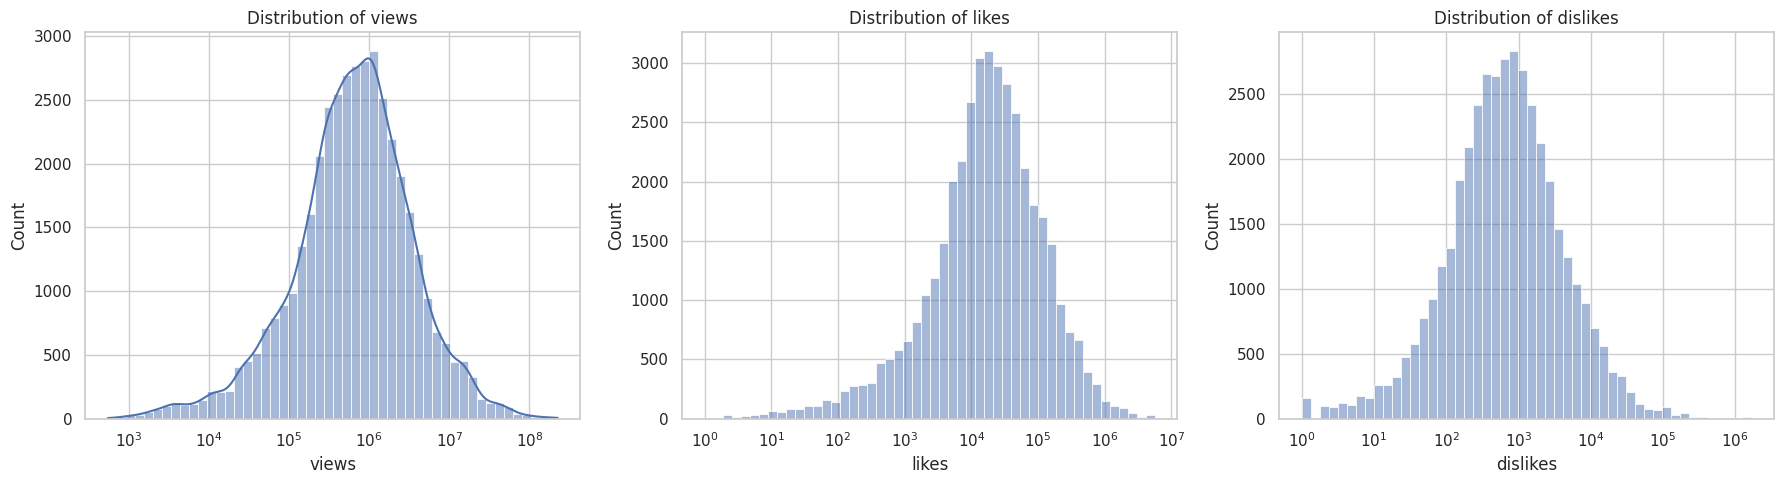

In [17]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(US_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

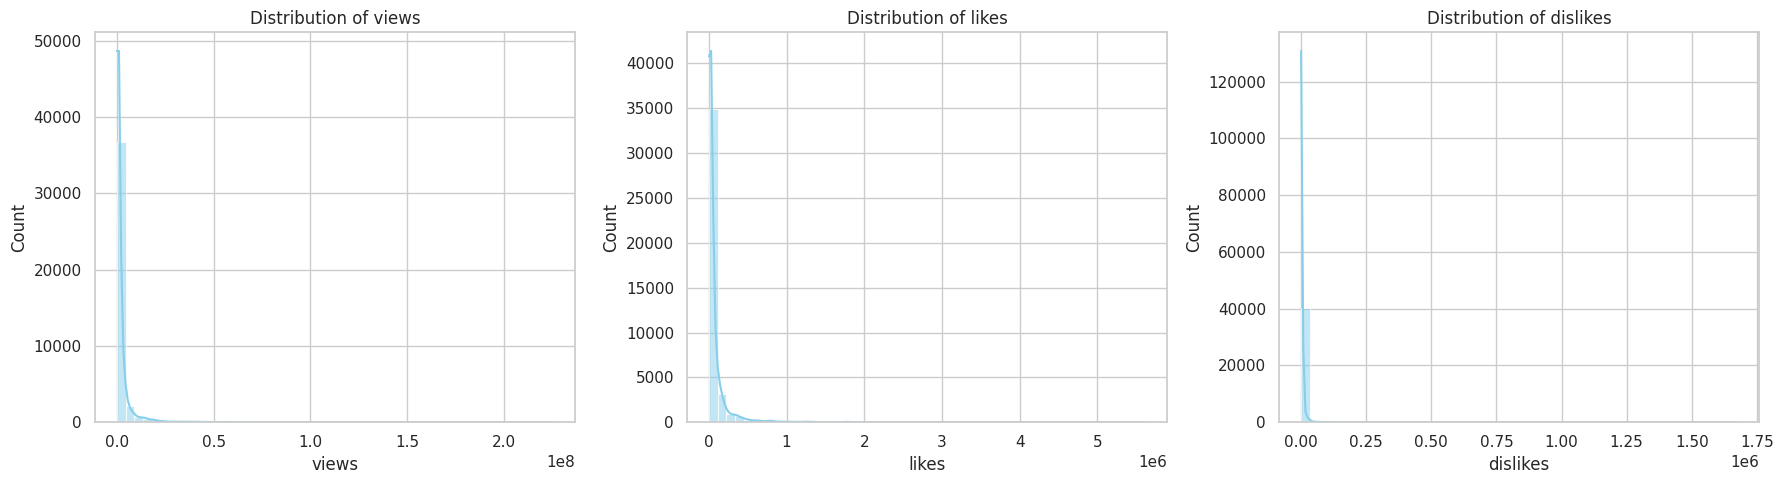

In [18]:
sns.set(style='whitegrid')

# Plot distributions (not log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(US_df[metric], bins=50, kde=True, ax=ax, color='skyblue')
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

Log scale	is useful for Skewed data, multiplicative growth (like YouTube views, income)	and it Compresses large values and spreads small ones.
Example:
If we have views like [100, 200, 500, 1000000]:
On linear scale: the last bar dominates.
On log scale: [log10(100)=2, log10(200)=2.3, log10(500)=2.7, log10(1000000)=6] — more balanced view.

So log-scaling is not just scaling — it’s a lens to reveal hidden structure in highly skewed data. For engagement metrics, it’s almost always the best first look.

#### CA-overall

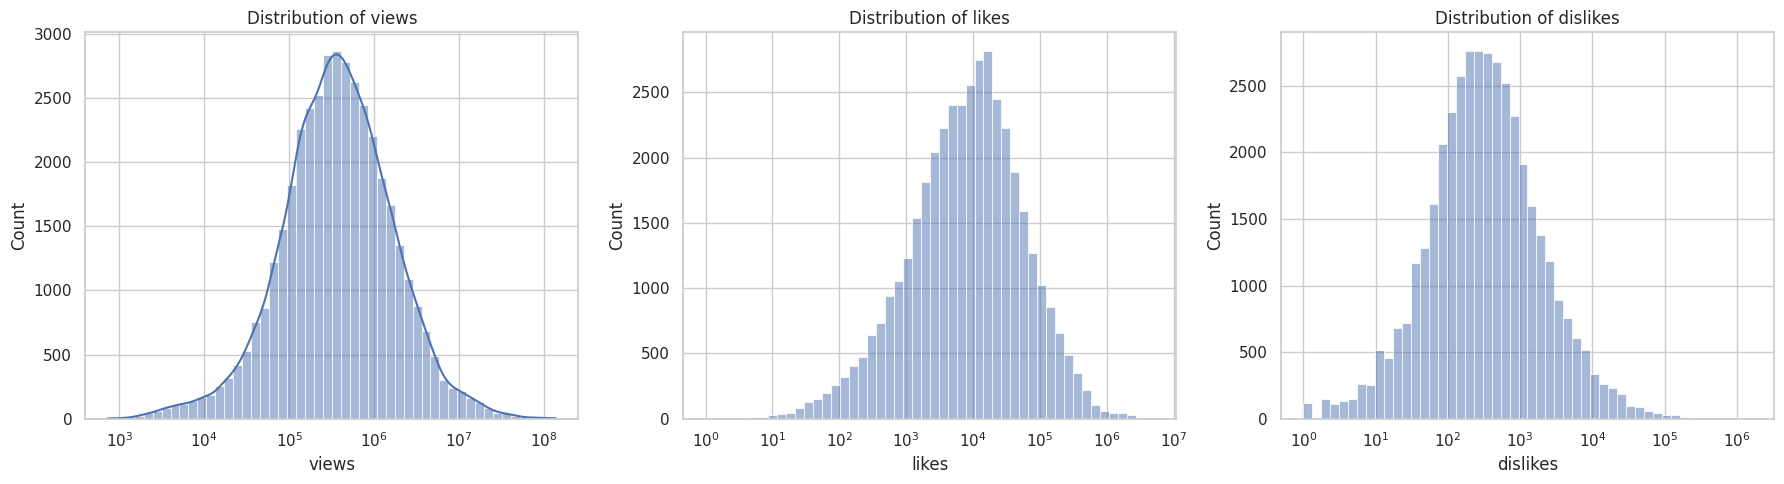

In [19]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(CA_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### DE-overall

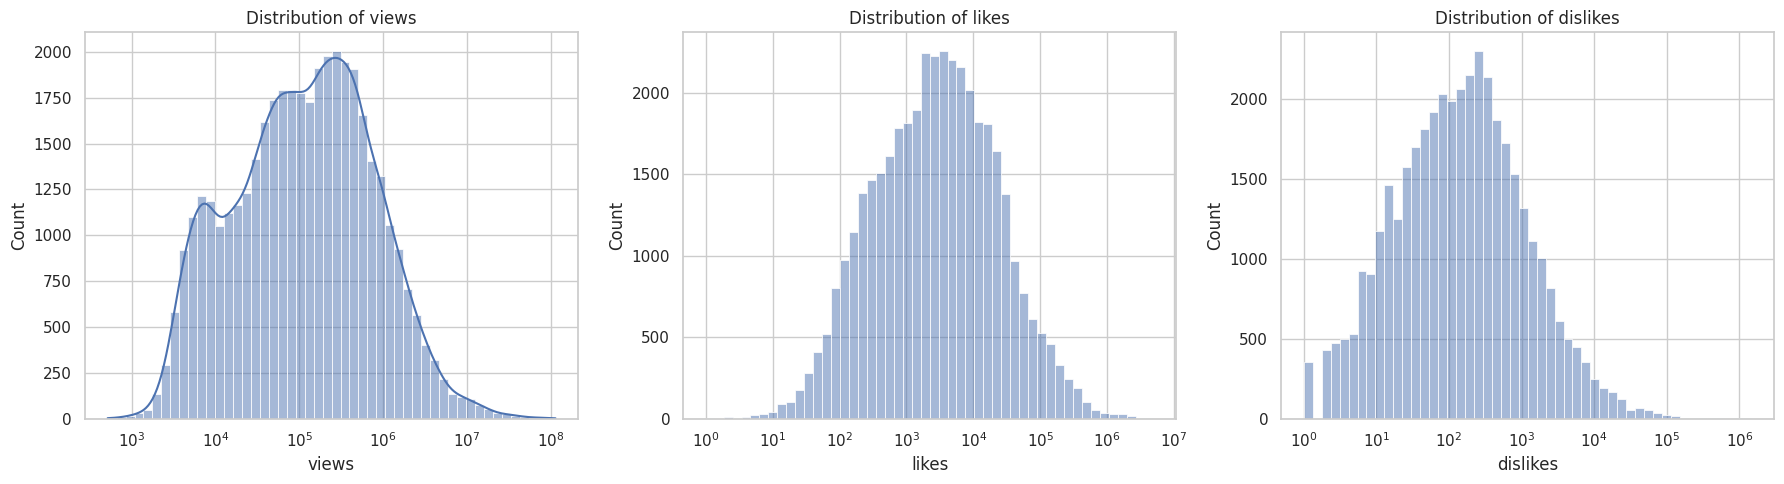

In [20]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(DE_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### FR-overall

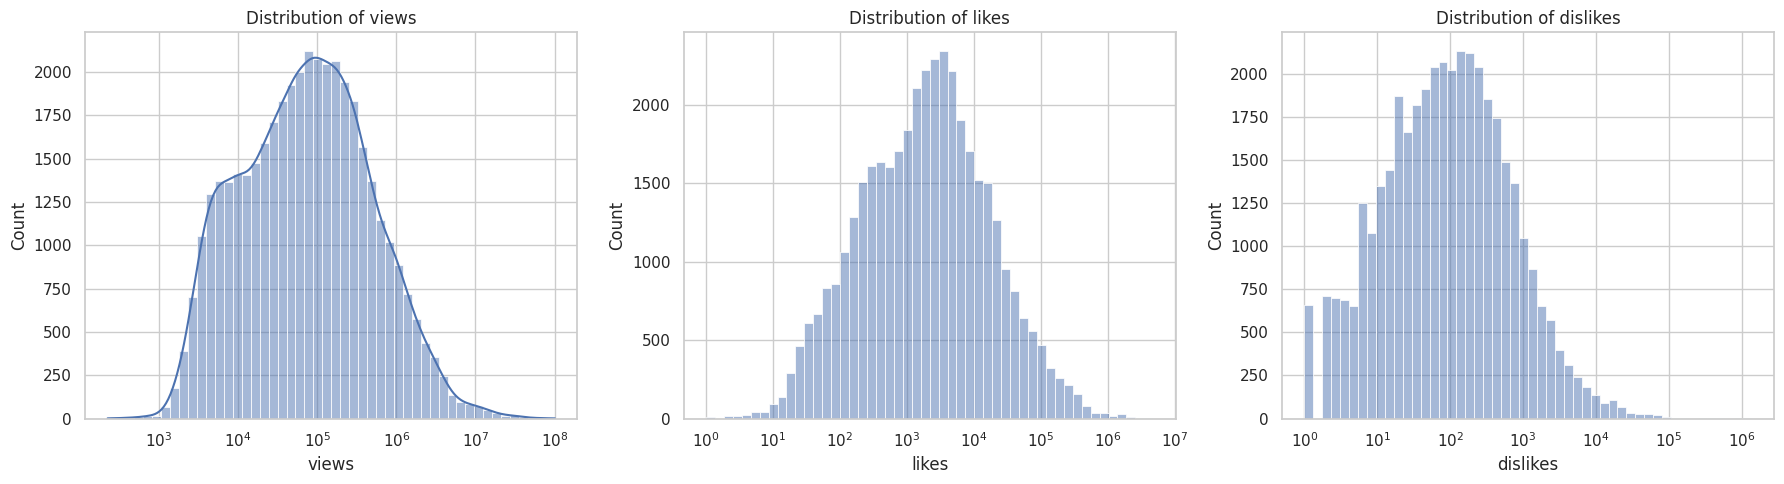

In [21]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(FR_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### GB-overall

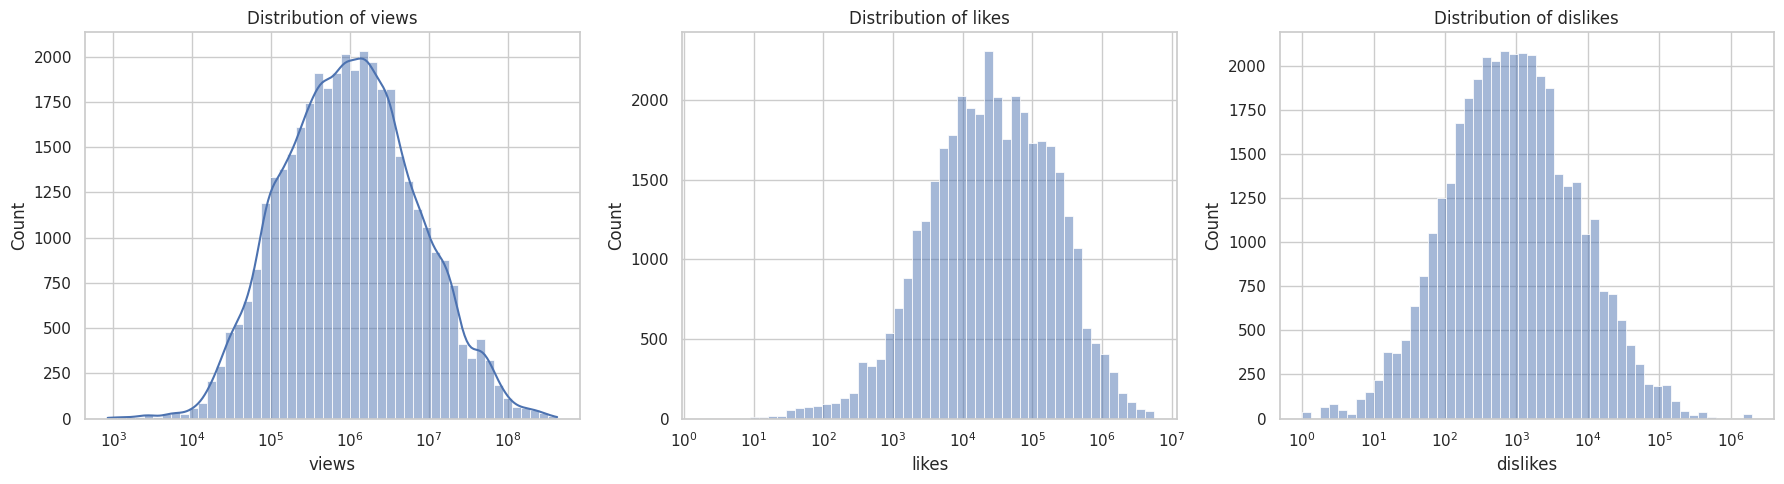

In [22]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(GB_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### IN-overall

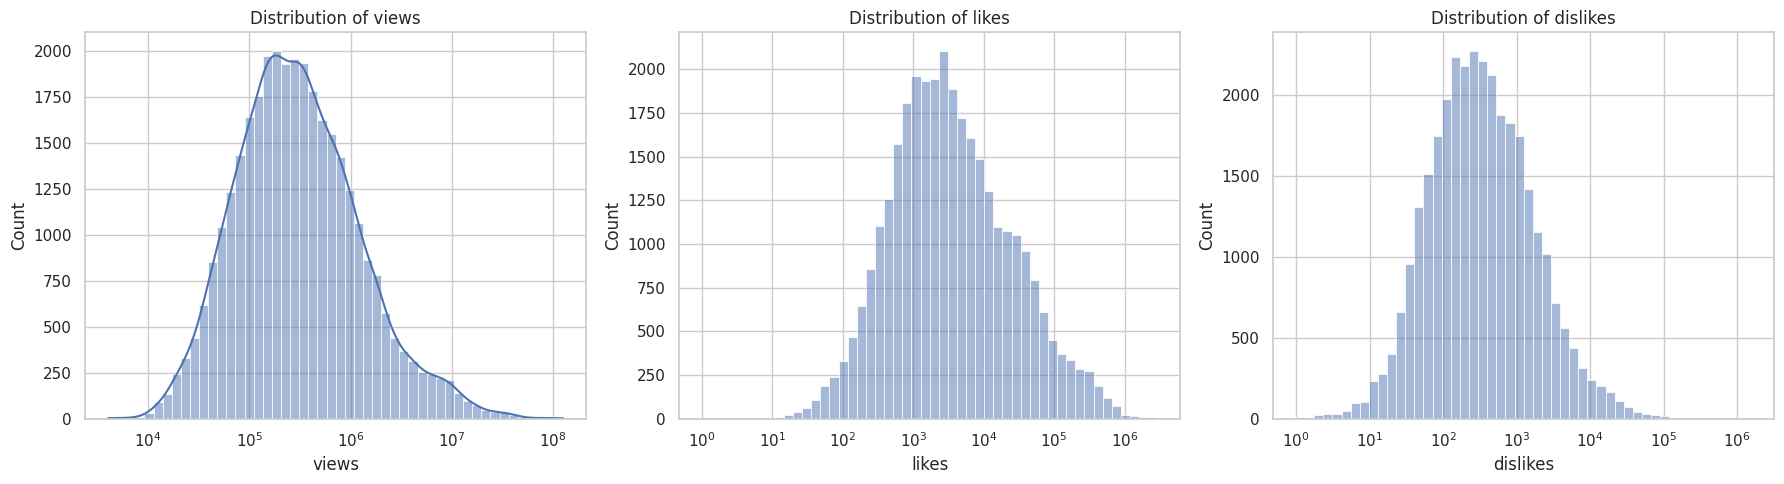

In [23]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(IN_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### JP-overall

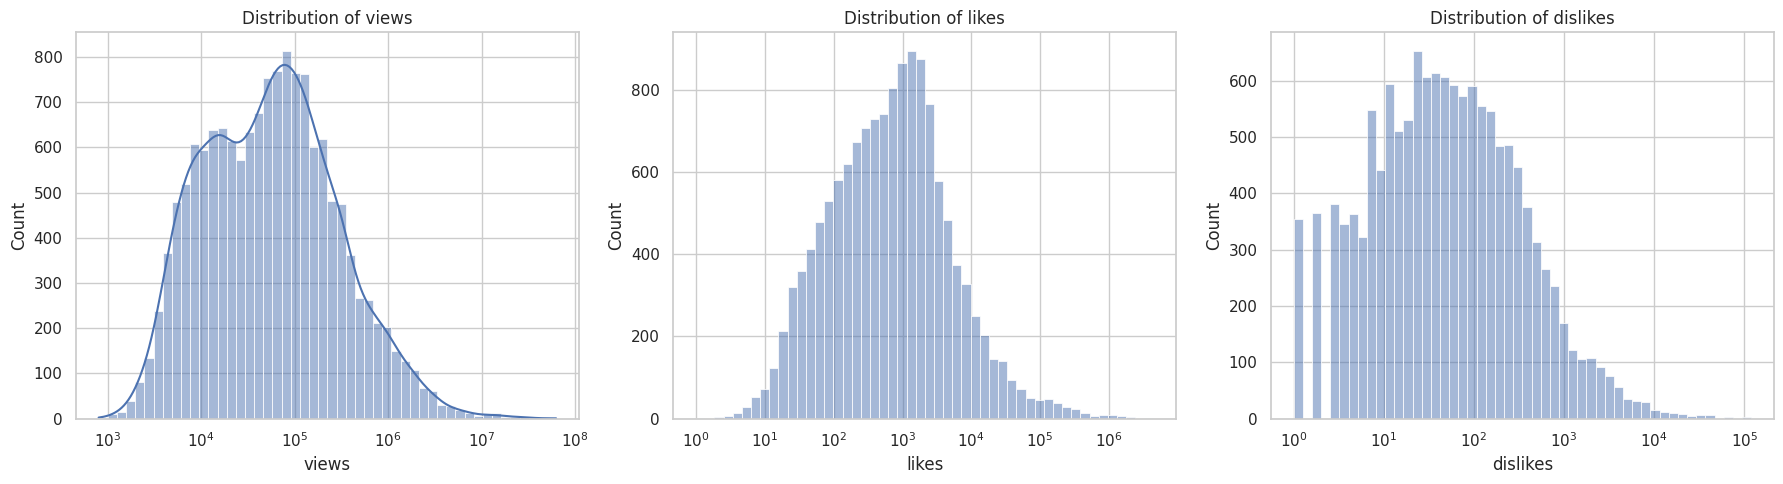

In [24]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(JP_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### KR-overall

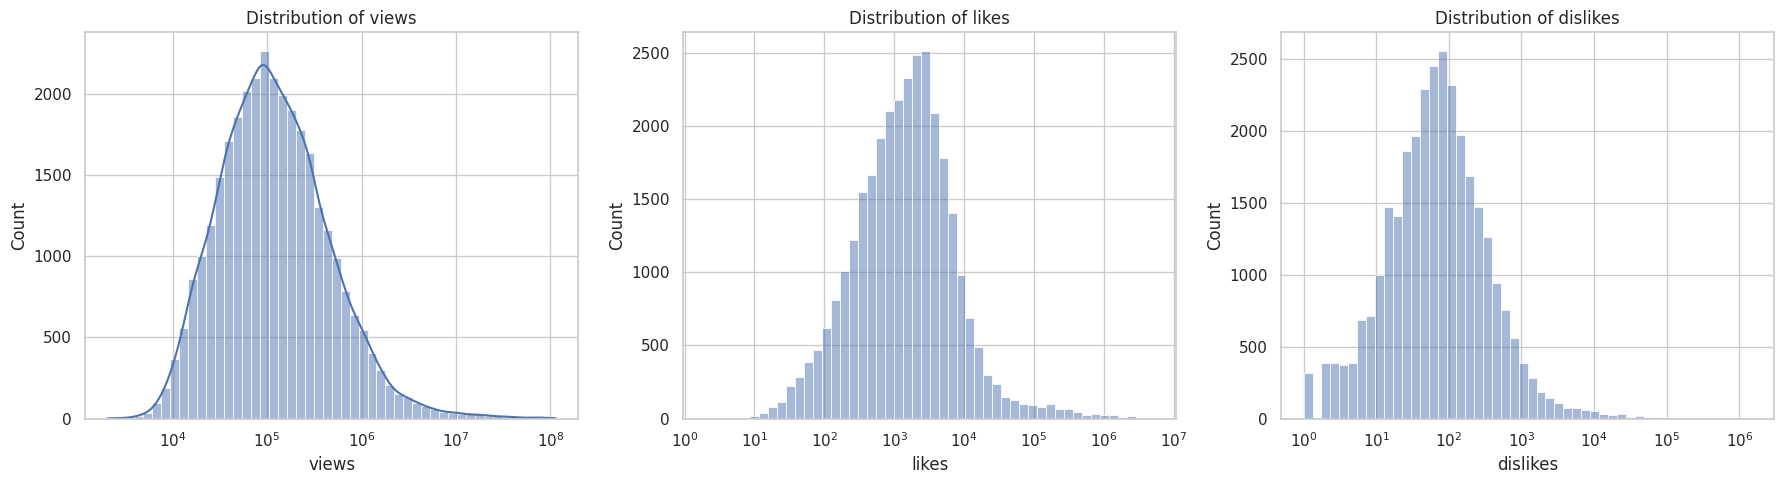

In [25]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(KR_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### MX-overall

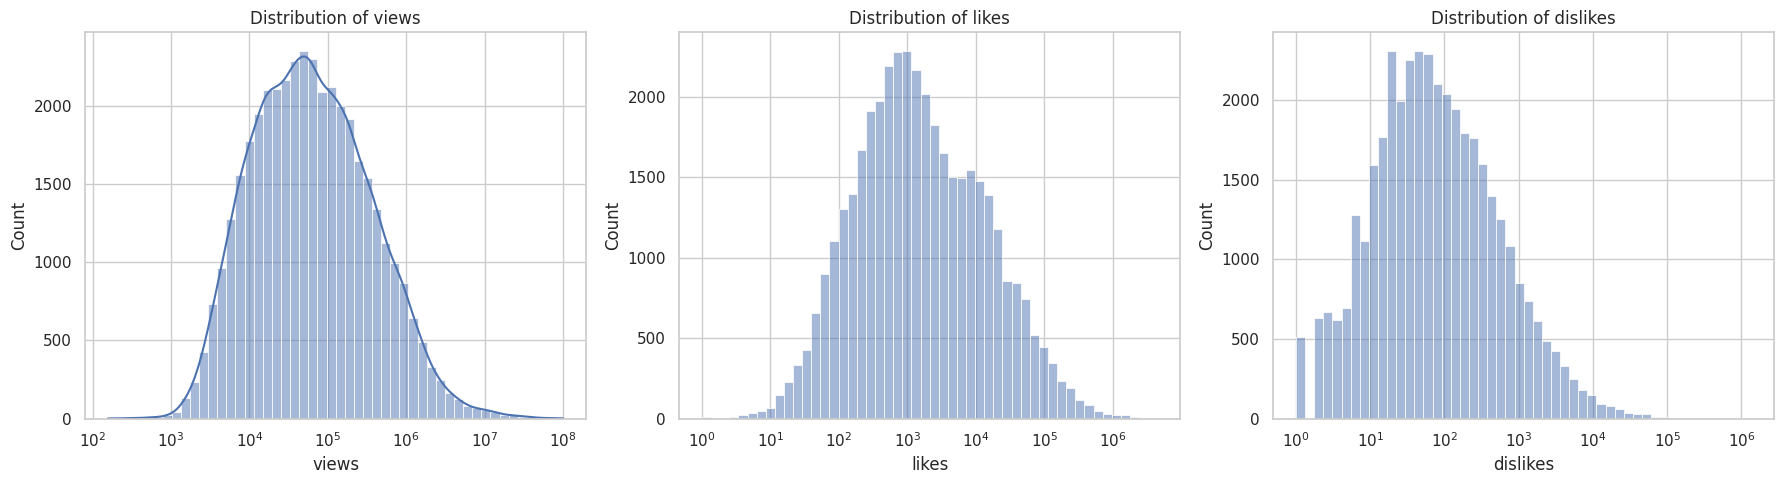

In [26]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(MX_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### RU-overall

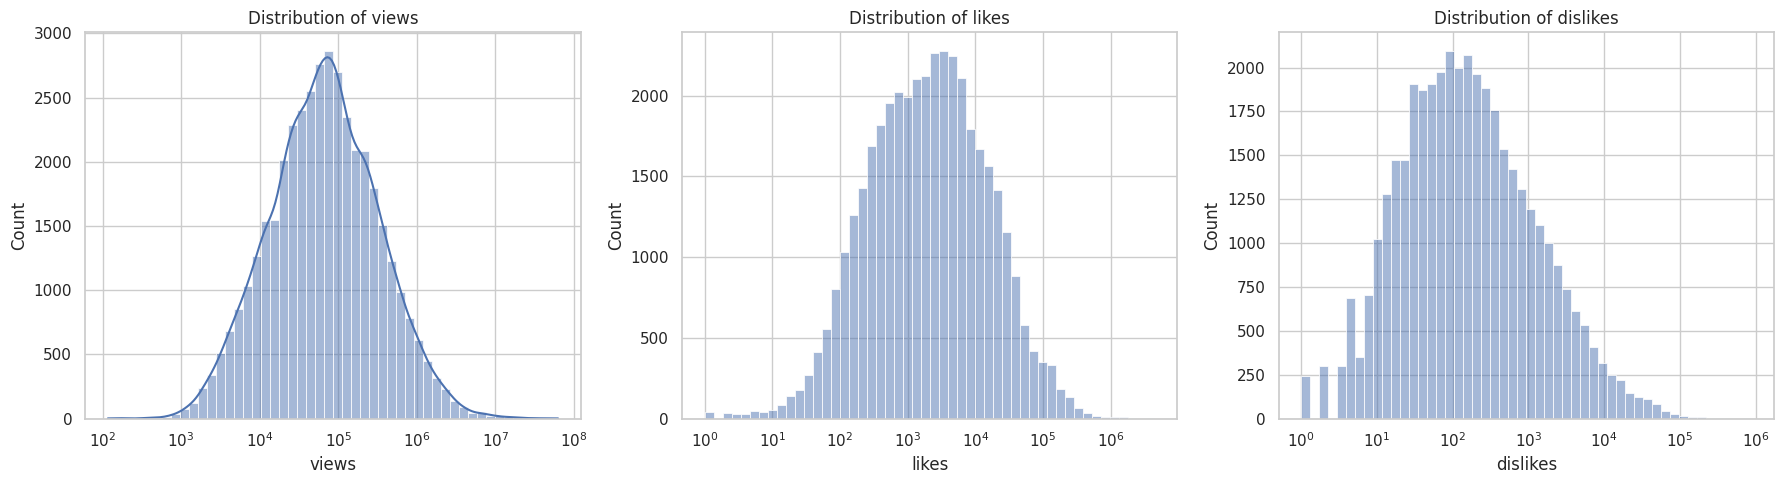

In [27]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(RU_df[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Globally-overall

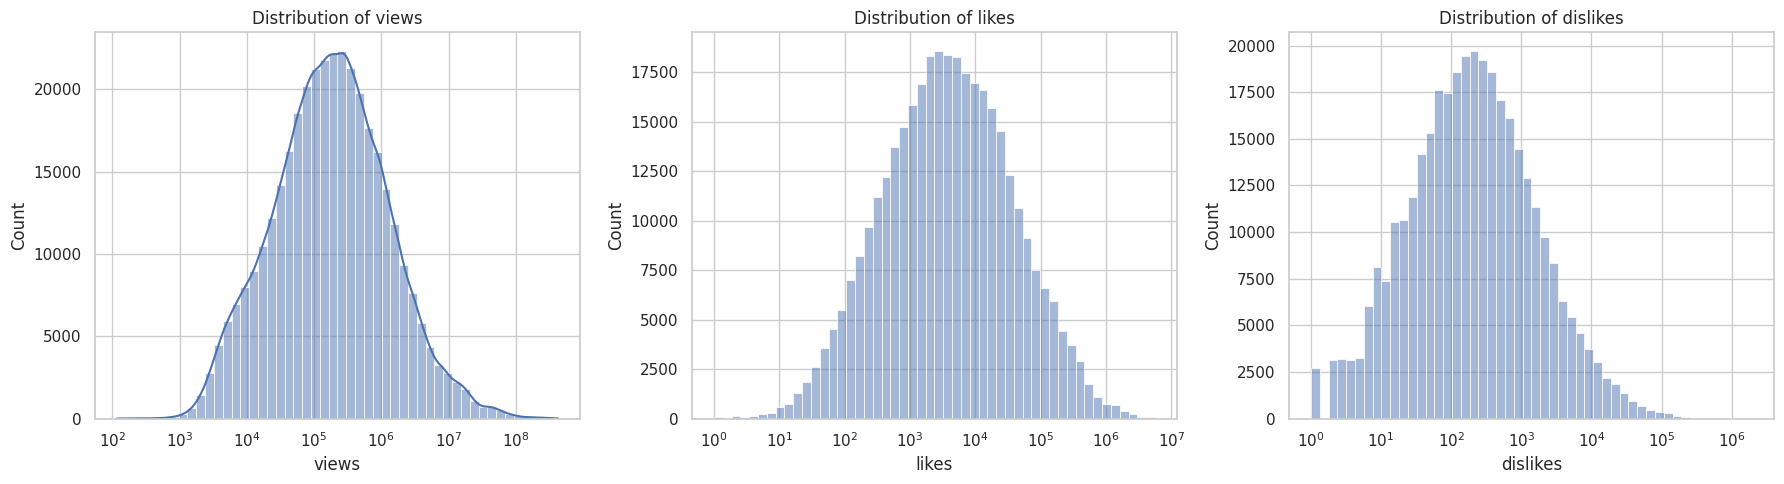

In [28]:
sns.set(style='whitegrid')

# Plot distributions of engagement metrics (log-scaled)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['views', 'likes', 'dislikes']):
    sns.histplot(df_global[metric], bins=50, kde=True, ax=ax, log_scale=(True, False))
    ax.set_title(f'Distribution of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

It is resonable that dislike plot is skewed, because a video is less likely to receive a lot of dislikes.

#### US-category

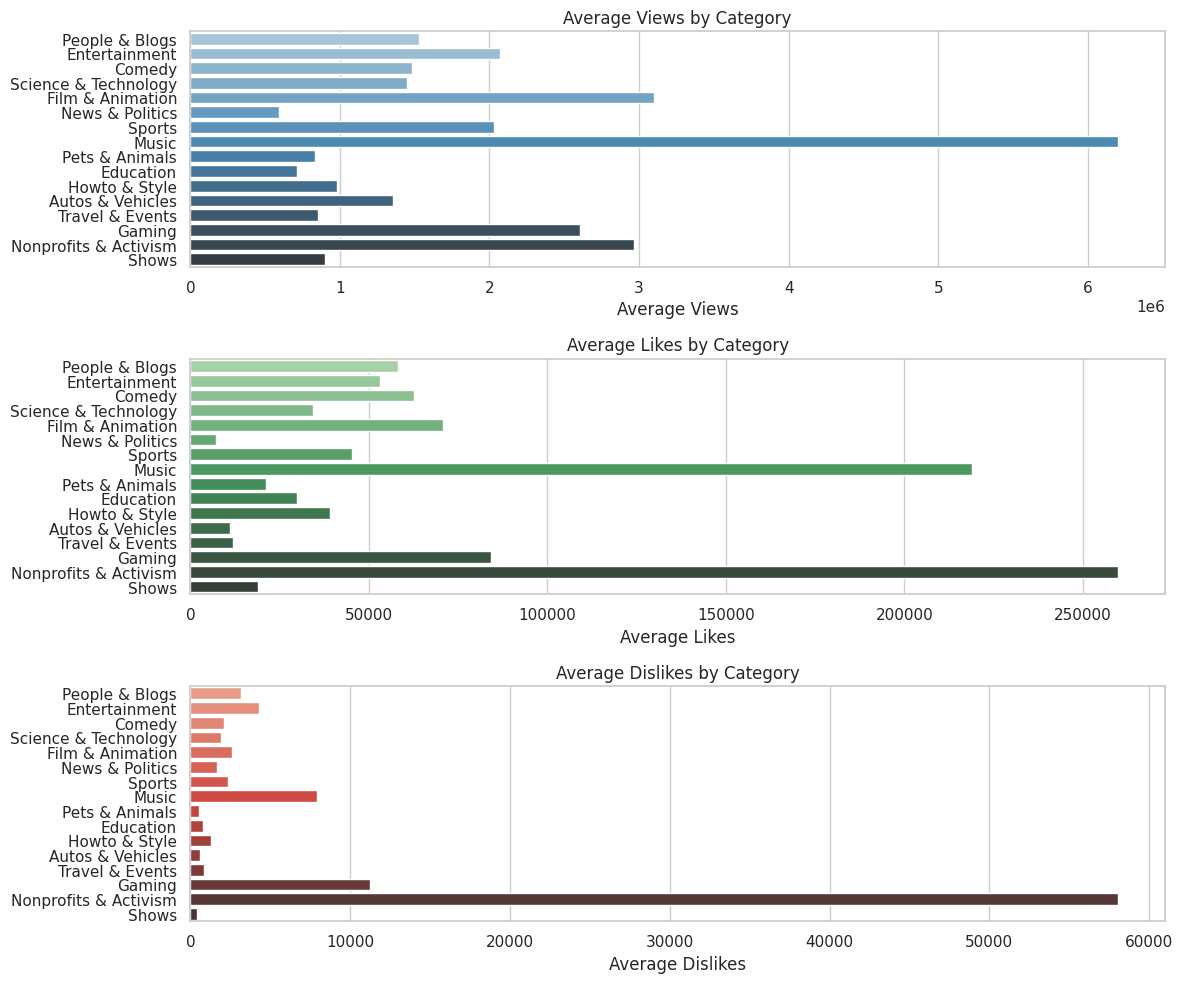

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=US_df, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=US_df, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=US_df, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

#### CA-category

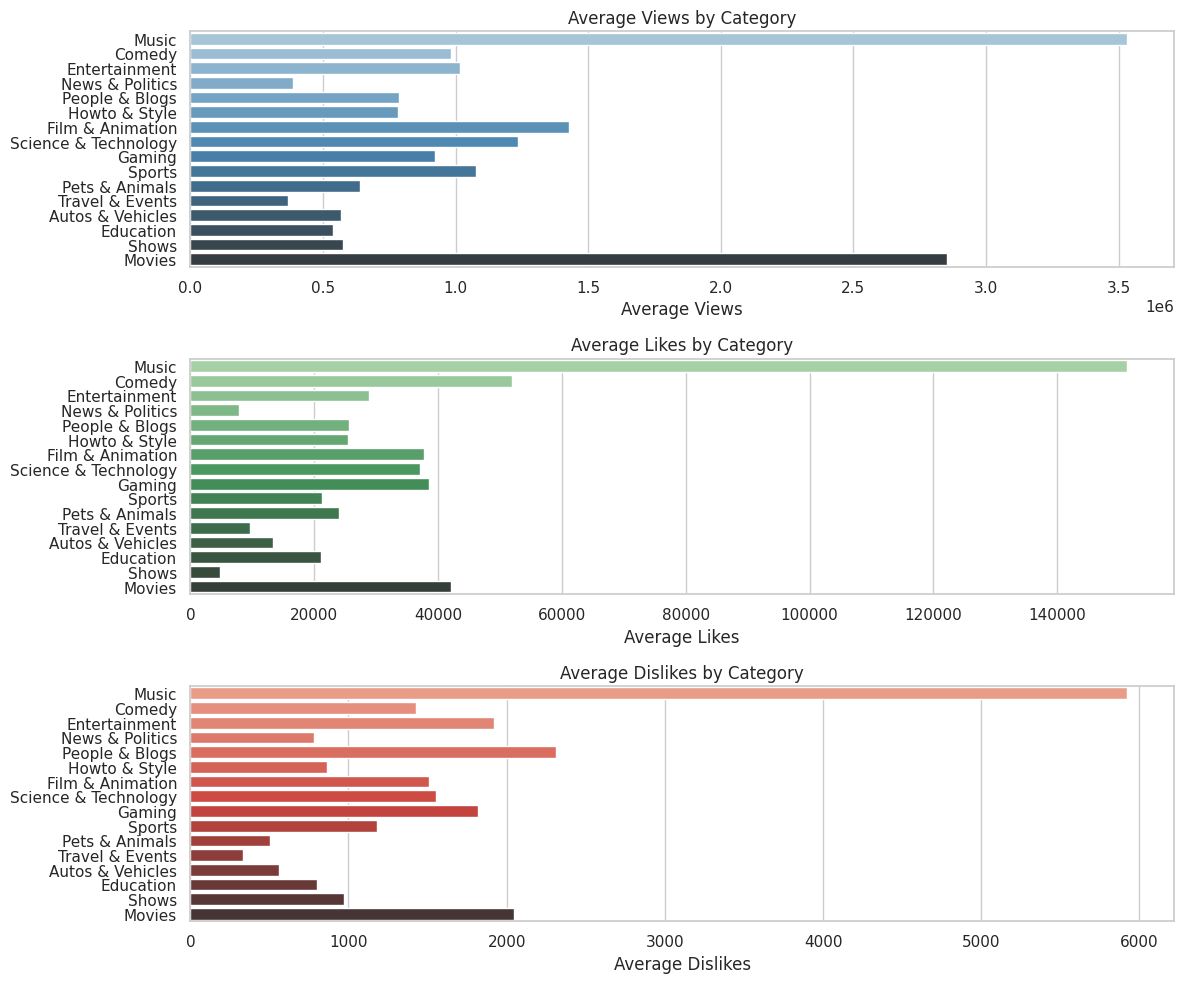

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=CA_df, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=CA_df, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=CA_df, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

#### FR-category

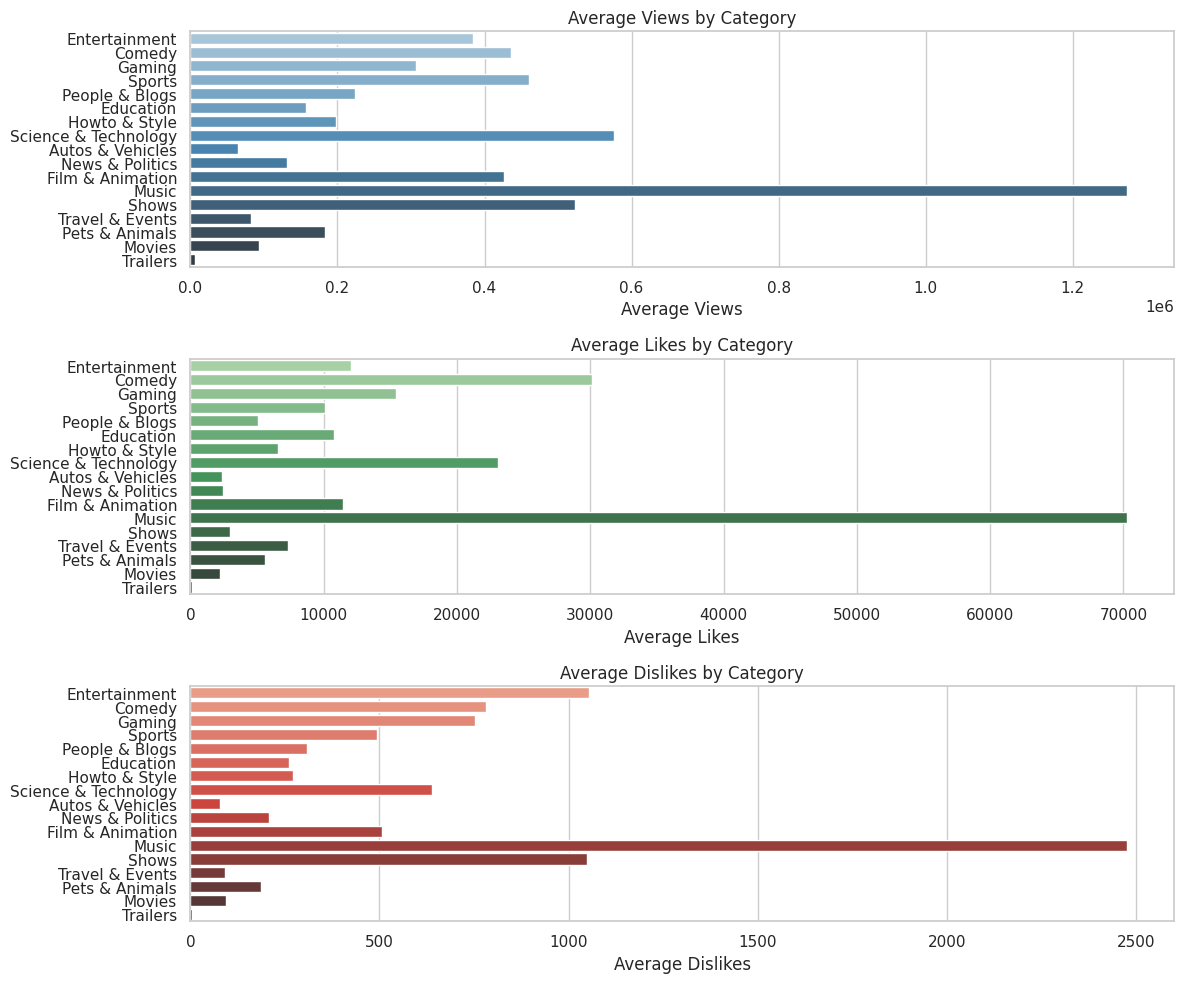

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=FR_df, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=FR_df, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=FR_df, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

#### JP-category

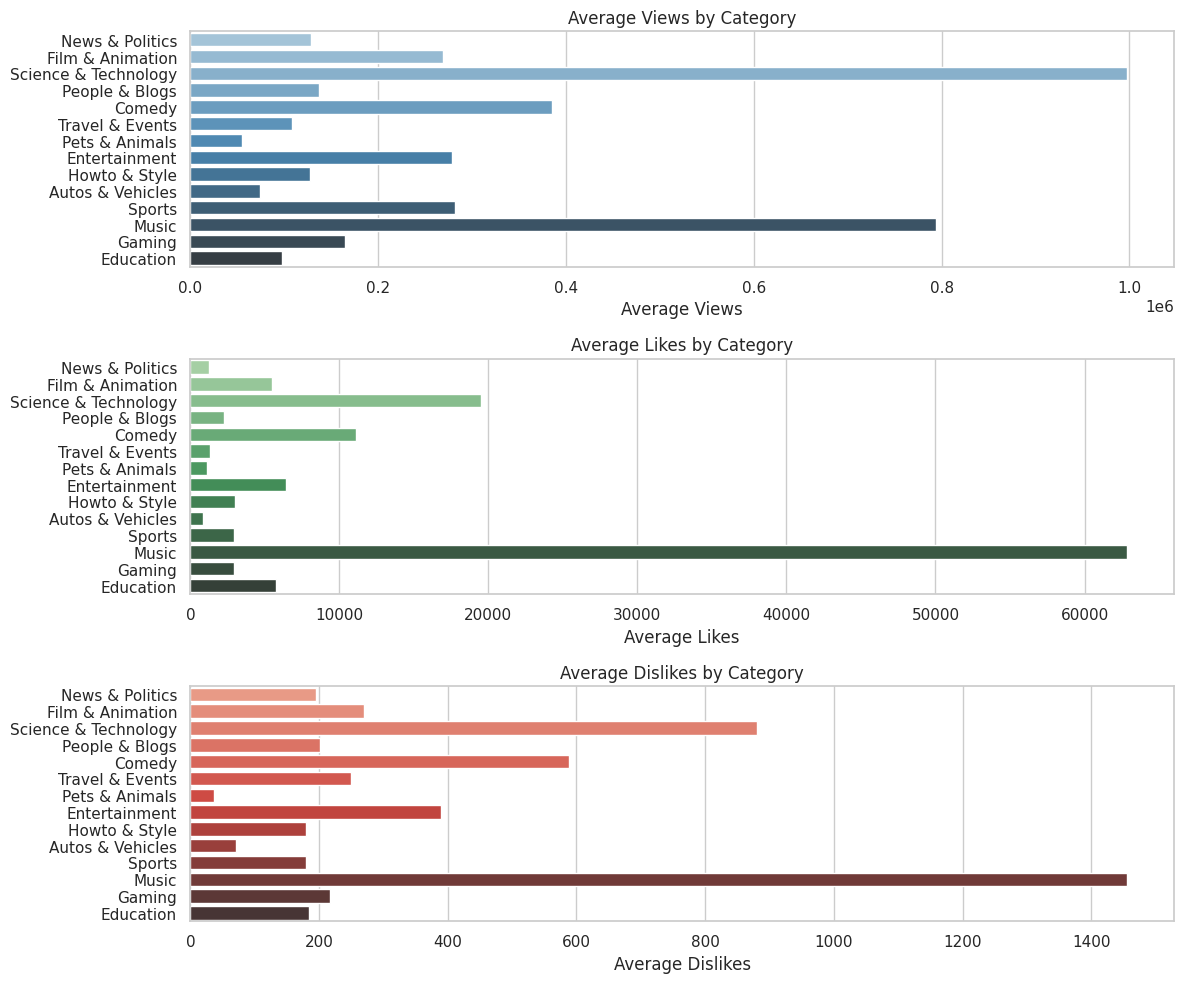

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=JP_df, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=JP_df, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=JP_df, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

#### KR-category

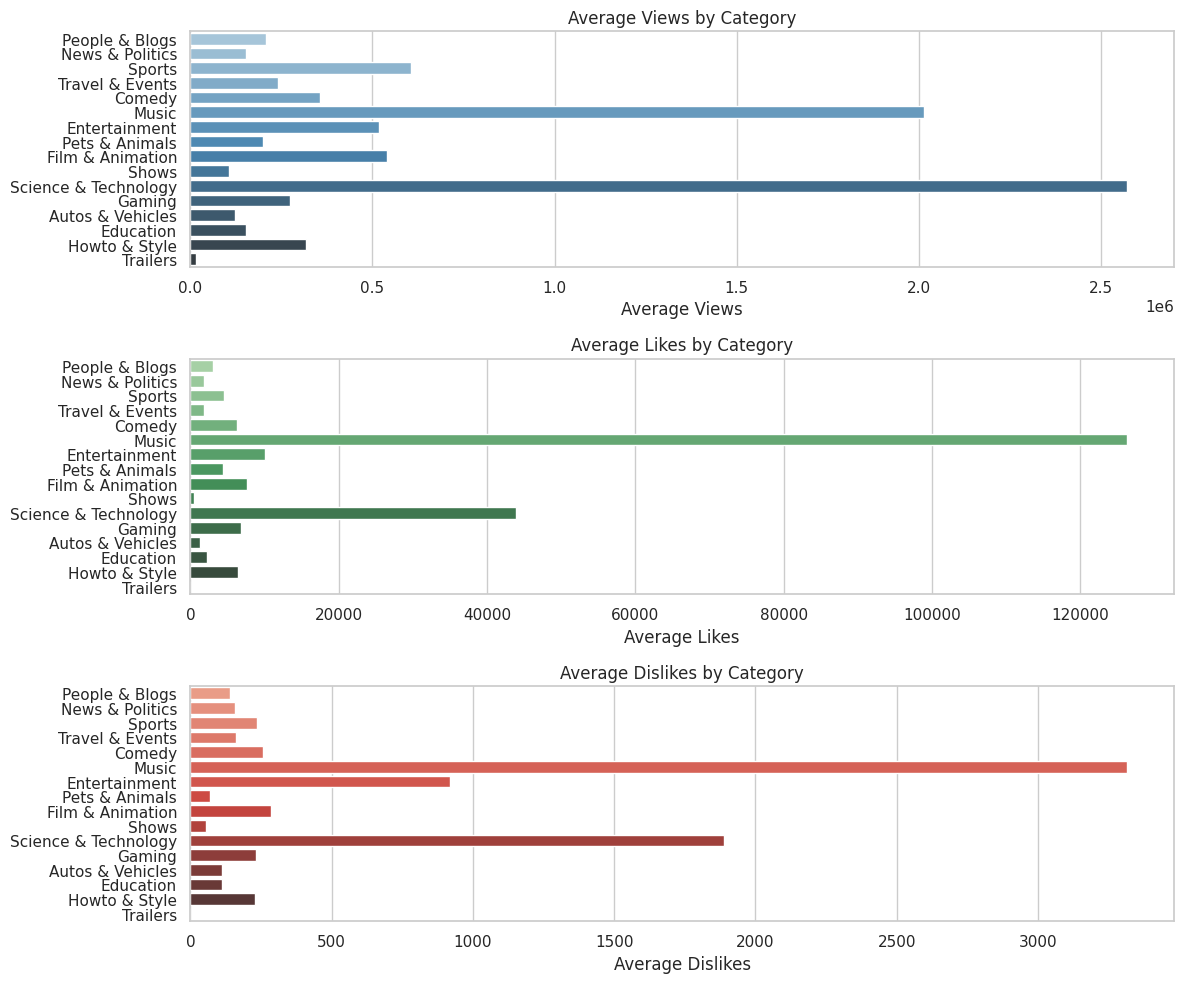

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=KR_df, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=KR_df, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=KR_df, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

#### MX-category

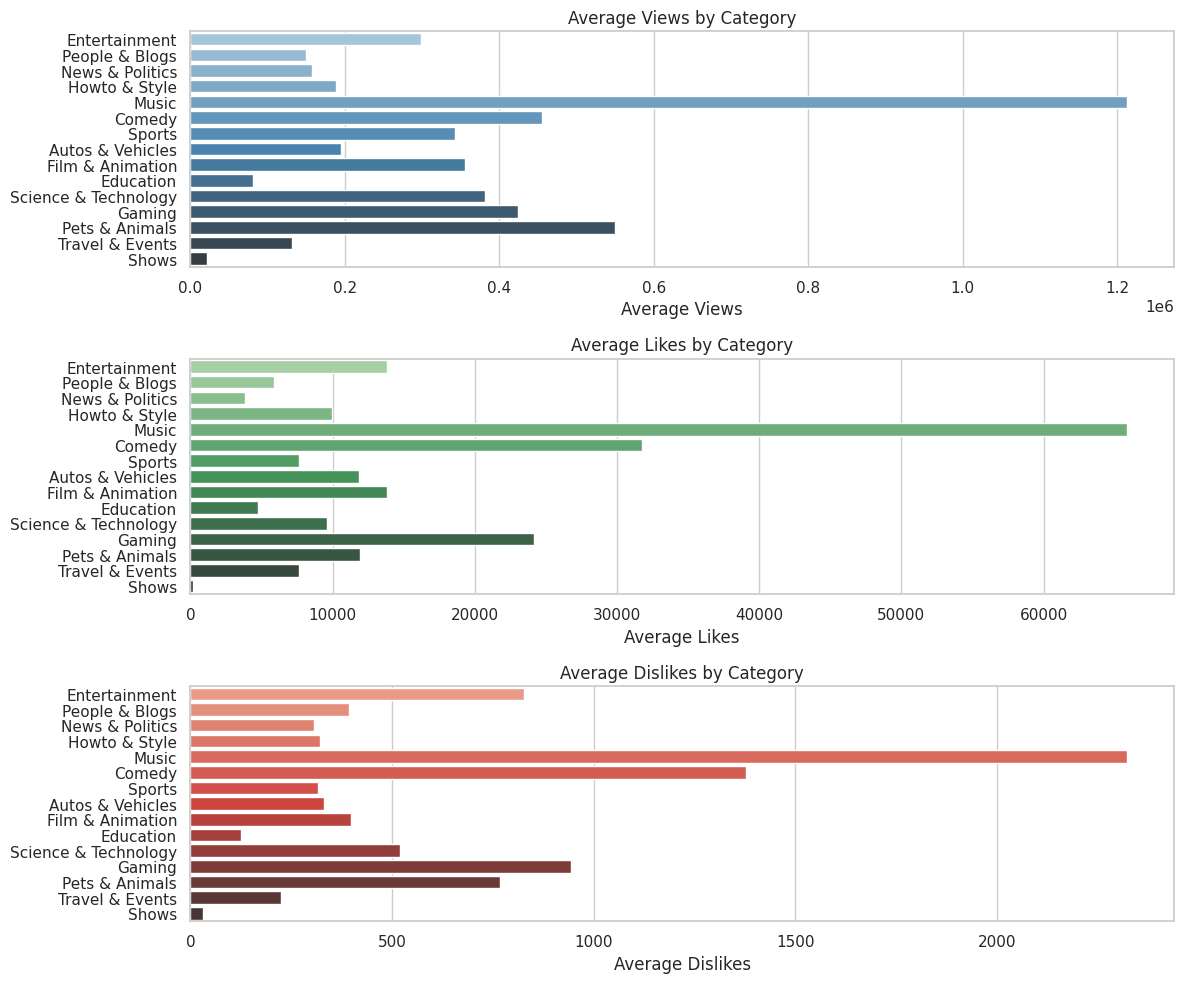

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=MX_df, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=MX_df, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=MX_df, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Countries with closer cultural backgrounds tend to show similar statistics across categories. For example, in South Korea and Japan, the "Science & Technology" category receives more engagement and in Mexico, "Comedy". "Music" usually ranks first almost everywhere.

#### Globally-category

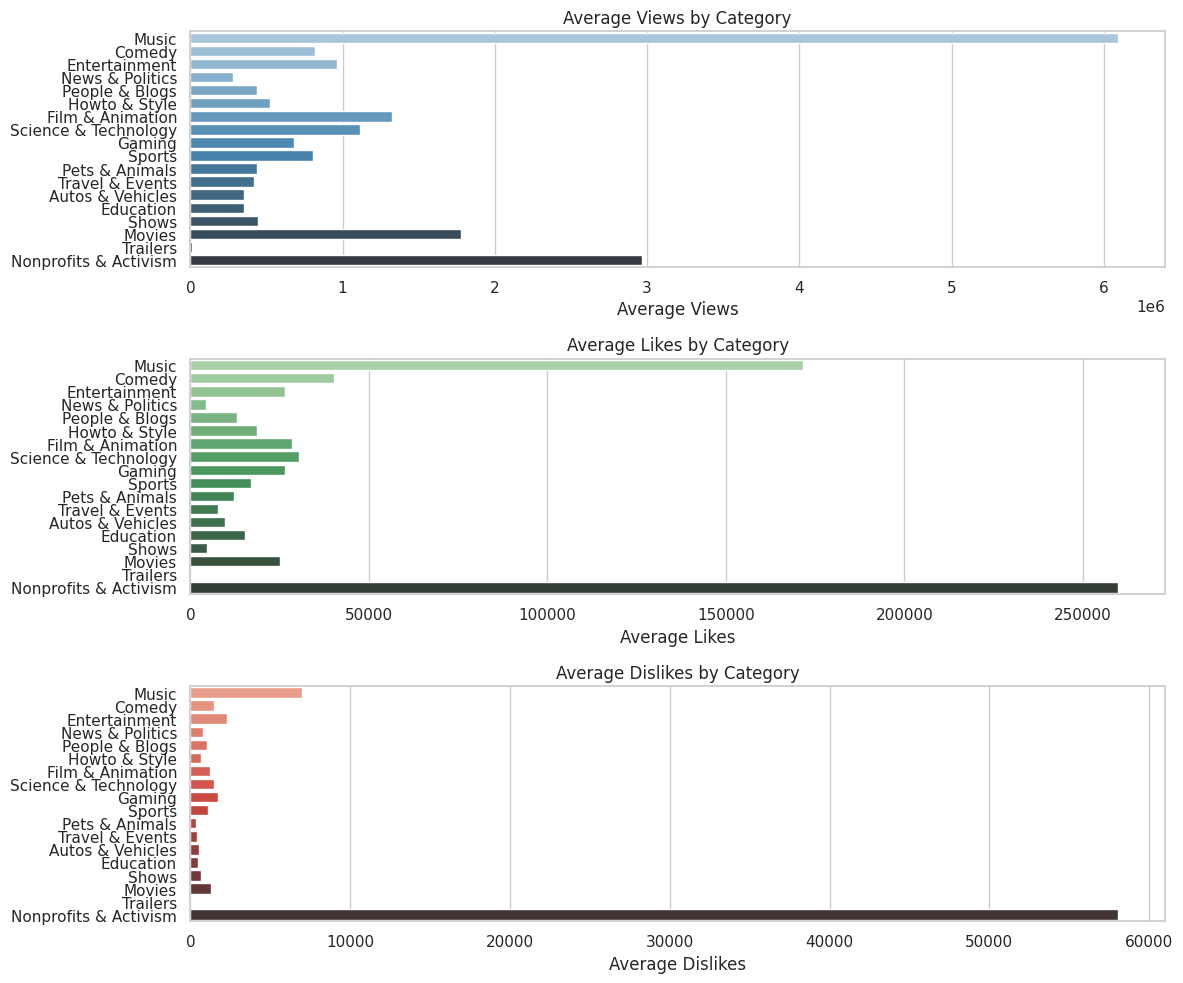

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

# Views
sns.barplot(x='views', y='category', data=df_global, estimator='mean', errorbar=None, ax=axes[0], hue='category', palette='Blues_d', legend=False)
axes[0].set_title('Average Views by Category')
axes[0].set_xlabel('Average Views')
axes[0].set_ylabel('')

# Likes
sns.barplot(x='likes', y='category', data=df_global, estimator='mean', errorbar=None, ax=axes[1], hue='category', palette='Greens_d', legend=False)
axes[1].set_title('Average Likes by Category')
axes[1].set_xlabel('Average Likes')
axes[1].set_ylabel('')

# Dislikes
sns.barplot(x='dislikes', y='category', data=df_global, estimator='mean', errorbar=None, ax=axes[2], hue='category', palette='Reds_d', legend=False)
axes[2].set_title('Average Dislikes by Category')
axes[2].set_xlabel('Average Dislikes')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

Globally, it is reasonable that the 'Nonprofits and Activism' category receives more feedback—both likes and dislikes—since it often reflects people's support or opposition to certain beliefs. The number of views remains highest in the Music category, which also makes sense.

In [36]:
category_engagement = df_global.groupby('category')[['views', 'likes', 'dislikes']].agg(['mean', 'median', 'std', 'count']).sort_values(('views', 'mean'), ascending=False)
category_engagement

views                                  \
                               mean    median           std   count   
category                                                              
Music                  6.094538e+06  935850.0  1.902557e+07   41454   
Nonprofits & Activism  2.963884e+06   73649.0  7.131112e+06      57   
Movies                 1.774643e+06  553851.0  2.337043e+06      30   
Film & Animation       1.327032e+06  197958.0  3.634317e+06   20193   
Science & Technology   1.115871e+06  315683.5  3.064517e+06    8068   
Entertainment          9.635065e+05  198682.0  4.199031e+06  104567   
Comedy                 8.203270e+05  345619.0  1.512525e+06   26077   
Sports                 8.078187e+05  173177.0  2.214011e+06   23035   
Gaming                 6.818134e+05  162806.0  1.644965e+06   11063   
Howto & Style          5.204091e+05  122998.0  1.279854e+06   18554   
Shows                  4.430091e+05  427780.0  4.163352e+05     909   
People & Blogs         4.407818e+05   71868.0  2.117769e+06   52297   
Pets & Animals         4.350063e+05  114069.0  8.918751e+05    4526   
Travel & Events        4.183125e+05  163980.0  1.155203e+06    1723   
Education              3.538062e+05   95796.5  8.098419e+05    7680   
Autos & Vehicles       3.529617e+05   95726.5  1.159998e+06    4678   
News & Politics        2.769876e+05   85347.5  7.898990e+05   35746   
Trailers               1.100860e+04    9804.0  6.171529e+03       5   

                               likes                                  \
                                mean   median            std   count   
category                                                               
Music                  171562.539803  38962.5  409645.940579   41454   
Nonprofits & Activism  259923.614035   2721.0  630711.782880      57   
Movies                  25083.866667  15679.5   27528.223591      30   
Film & Animation        28467.353885   3557.0   72239.753778   20193   
Science & Technology    30534.580813  12111.5   56746.889659    8068   
Entertainment           26483.093509   3306.0  116167.267826  104567   
Comedy                  40245.188442  13096.0   78957.205266   26077   
Sports                  17095.653831   2134.0   77793.541448   23035   
Gaming                  26612.778360   6559.0   69272.533023   11063   
Howto & Style           18614.234882   5019.0   37050.830330   18554   
Shows                    4758.035204   2840.0    8113.681132     909   
People & Blogs          13077.590760   1215.0   53789.290134   52297   
Pets & Animals          12332.781485   3736.0   23723.436240    4526   
Travel & Events          7790.409750   4910.0   11656.831108    1723   
Education               15204.658594   3717.0   37667.082218    7680   
Autos & Vehicles         9682.200513   3696.0   16275.785588    4678   
News & Politics          4453.574582   1002.0   21285.120222   35746   
Trailers                   39.600000      3.0      59.449979       5   

                           dislikes                                
                               mean median            std   count  
category                                                           
Music                   6981.860158  916.0   22311.081753   41454  
Nonprofits & Activism  58076.859649  122.0  147565.569602      57  
Movies                  1265.400000  502.5    1544.659378      30  
Film & Animation        1210.786906  165.0    3457.098475   20193  
Science & Technology    1488.003594  436.0    3643.305255    8068  
Entertainment           2321.269072  195.0   38285.198323  104567  
Comedy                  1502.224182  399.0    4263.488498   26077  
Sports                  1136.932885  118.0    8677.782479   23035  
Gaming                  1745.657959  182.0   10925.723562   11063  
Howto & Style            679.286407  153.0    1884.554945   18554  
Shows                    681.687569  483.0    1196.554182     909  
People & Blogs          1068.623898   72.0    8410.498960   52297  
Pets 

### Top Trending Channels and Video Categories

#### Which video categories trend the most in each country?

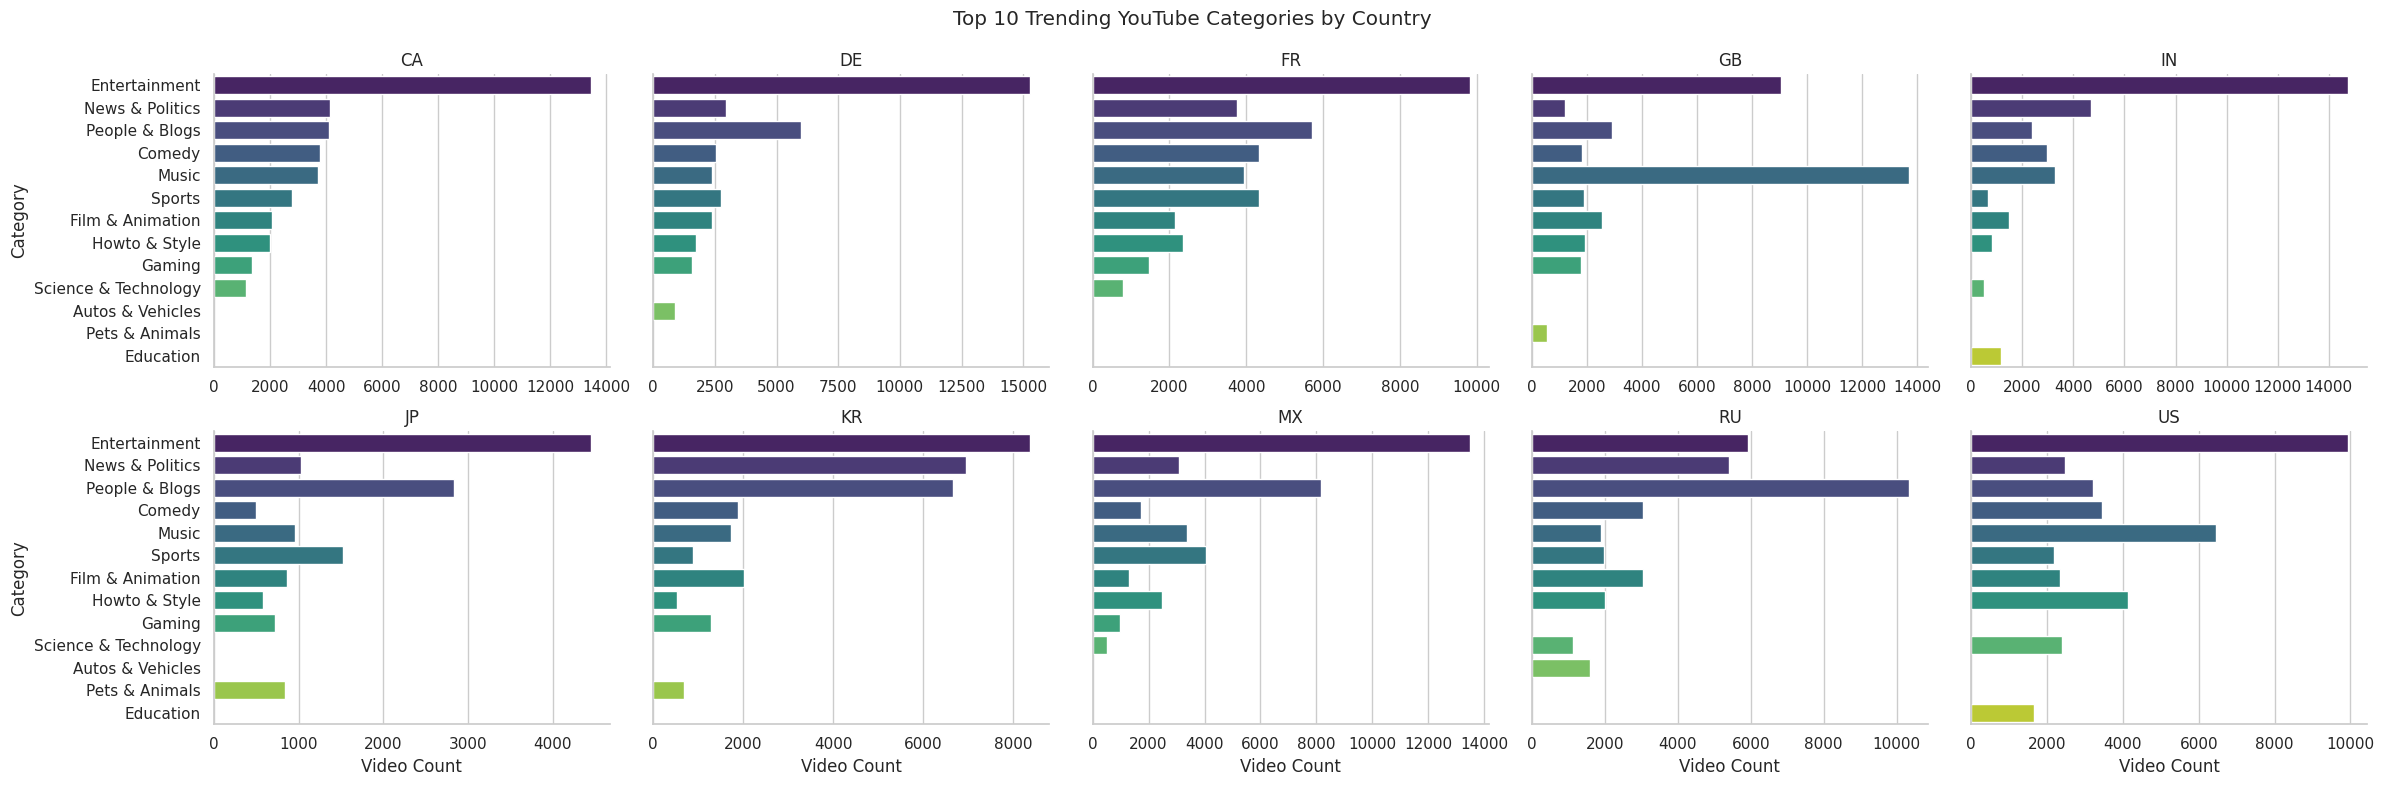

In [37]:
# Create a DataFrame with country, category, and count
category_data = []

for country, df in zip(country_codes, dfs):
    top_cats = df['category'].value_counts().head(10)
    for cat, count in top_cats.items():
        category_data.append({'country': country, 'category': cat, 'count': count})

category_df = pd.DataFrame(category_data)

# Set up the visualization
g = sns.catplot(
    data=category_df,
    x="count", y="category", col="country",
    kind="bar", col_wrap=5, height=4, aspect=1.2,
    hue="category",
    palette="viridis",
    legend=False,
    sharex=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Video Count", "Category")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Top 10 Trending YouTube Categories by Country")

plt.show()

#### Which video categories trend the most in global?

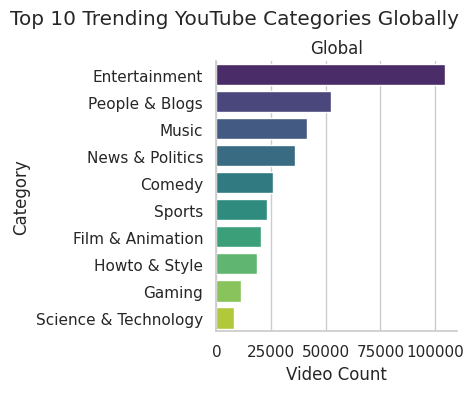

In [38]:
# Count top 10 categories globally
top_global_cats = df_global['category'].value_counts().head(10)

# Build a DataFrame for plotting
category_df_global = pd.DataFrame({
    'category': top_global_cats.index,
    'count': top_global_cats.values,
    'country': ['Global'] * 10
})

g = sns.catplot(
    data=category_df_global,
    x="count", y="category", col="country",
    kind="bar", height=4, aspect=1.2,
    hue="category",
    palette="viridis",
    legend=False,
    sharex=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Video Count", "Category")
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("Top 10 Trending YouTube Categories Globally")

plt.show()

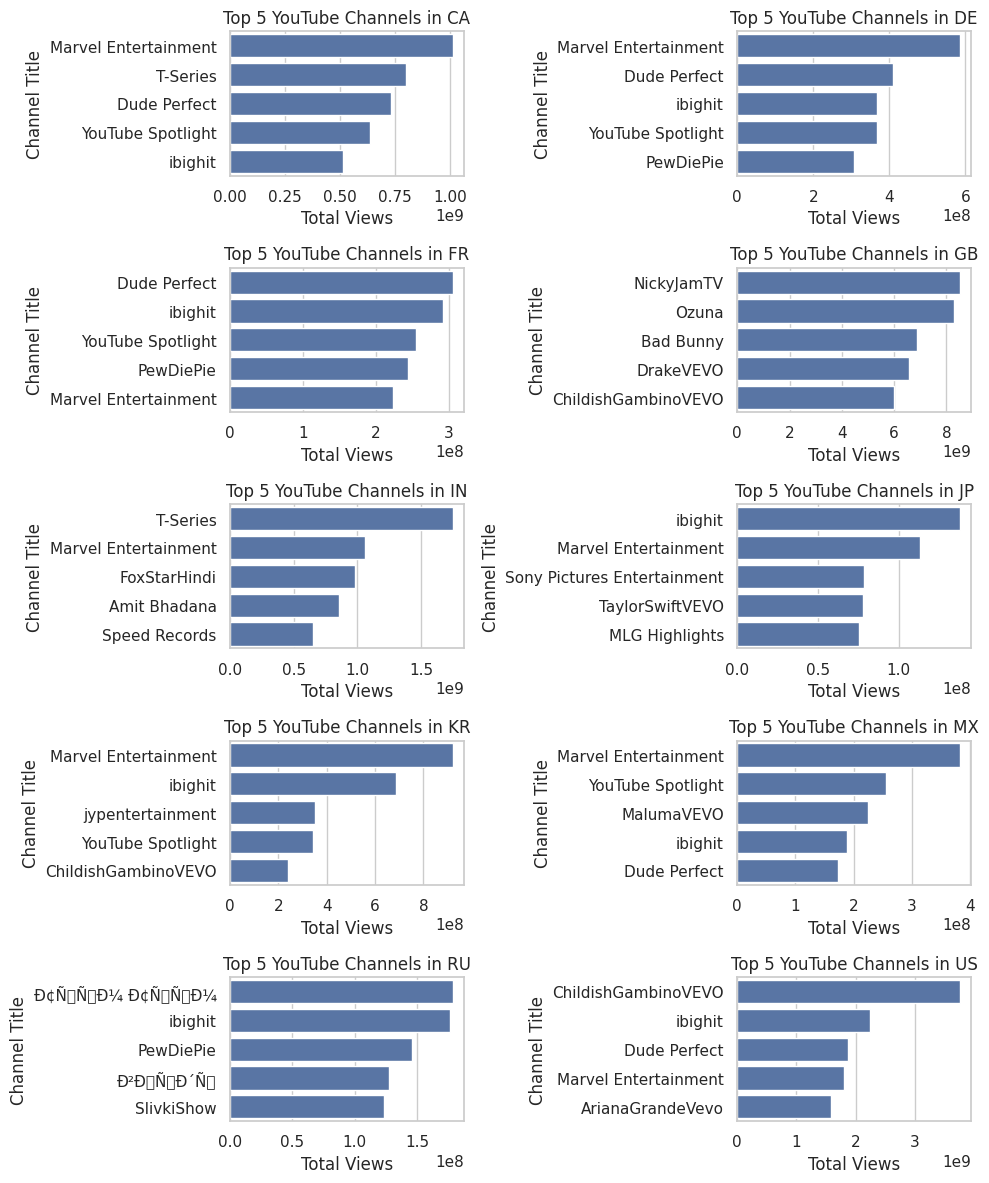

In [39]:
countries = df_global['country'].unique()

fig, axes = plt.subplots(5, 2, figsize=(10, 12))
axes = axes.flatten()


for i, country in enumerate(countries[:10]):
    country_data = df_global[df_global['country'] == country].groupby('channel_title')['views'].sum().reset_index()
    country_data = country_data.sort_values(by='views', ascending=False).head(5)
    sns.barplot(x='views', y='channel_title', data=country_data, ax=axes[i])


    axes[i].set_title(f'Top 5 YouTube Channels in {country}')
    axes[i].set_xlabel('Total Views')
    axes[i].set_ylabel('Channel Title')

plt.tight_layout()
plt.show()

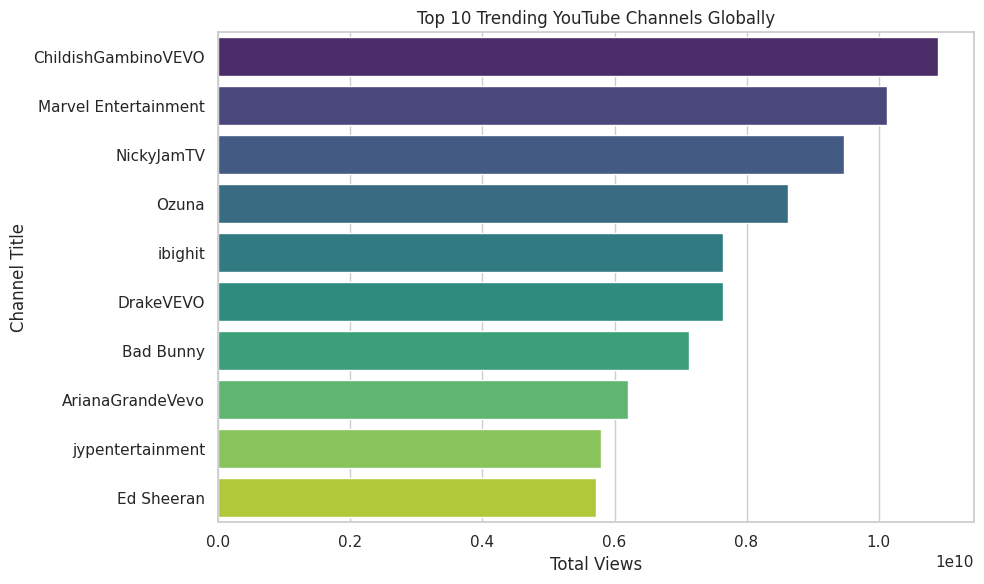

In [40]:
# Group by channel title and sum views
top_global_channels = df_global.groupby("channel_title")["views"].sum().sort_values(ascending=False).head(10).reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x="views", y="channel_title", data=top_global_channels, palette="viridis")
plt.title("Top 10 Trending YouTube Channels Globally")
plt.xlabel("Total Views")
plt.ylabel("Channel Title")
plt.tight_layout()
plt.show()

### Time Impact

#### Are there seasonal or day-of-week patterns in trending videos?

<br>

* day-of-week:

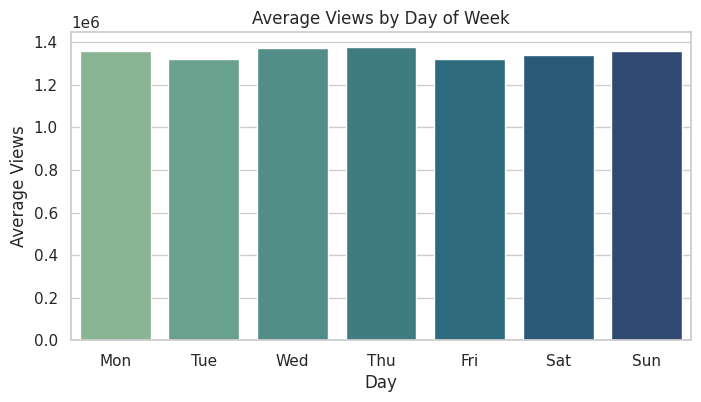

In [41]:
df_global['day_of_week'] = df_global['trending_date'].dt.dayofweek

# Map to day names
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df_global['day_name'] = df_global['day_of_week'].map(day_map)

# Group by and aggregate views
day_stats = df_global.groupby('day_name')['views'].mean().reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=day_stats.index, y=day_stats.values, palette='crest')
plt.title('Average Views by Day of Week')
plt.ylabel('Average Views')
plt.xlabel('Day')
plt.show()


* Seasonal:

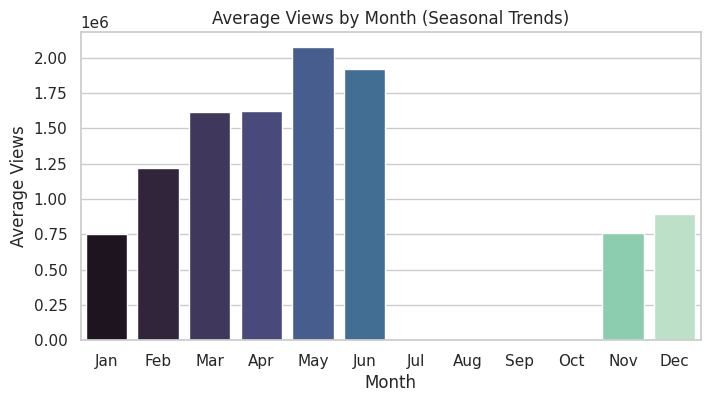

In [42]:
df_global['month'] = df_global['trending_date'].dt.month
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
df_global['month_name'] = df_global['month'].map(month_map)

# Group by and aggregate views
month_stats = df_global.groupby('month_name')['views'].mean().reindex(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(x=month_stats.index, y=month_stats.values, palette='mako')
plt.title('Average Views by Month (Seasonal Trends)')
plt.ylabel('Average Views')
plt.xlabel('Month')
plt.show()


#### How does the upload day and time impact video engagement?

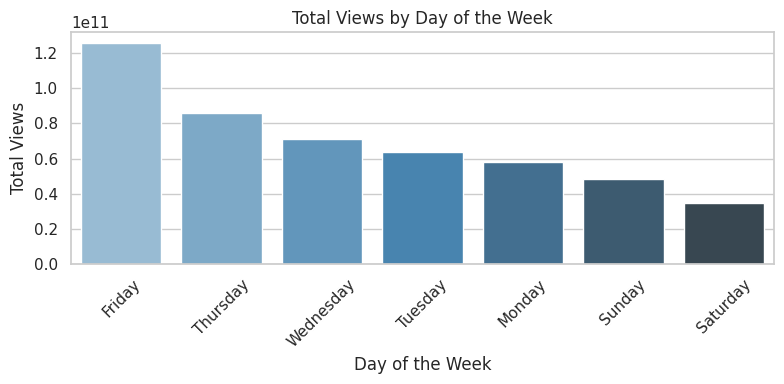

In [43]:
# Extract day of week
df_global['publish_day'] = df_global['publish_time'].dt.day_name()

# Group by day and get totals
day_totals = df_global.groupby('publish_day')[['views', 'likes', 'dislikes']].sum().reset_index()
day_totals = day_totals.sort_values('views', ascending=False)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=day_totals, x='publish_day', y='views', palette='Blues_d')
plt.title('Total Views by Day of the Week')
plt.ylabel('Total Views')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


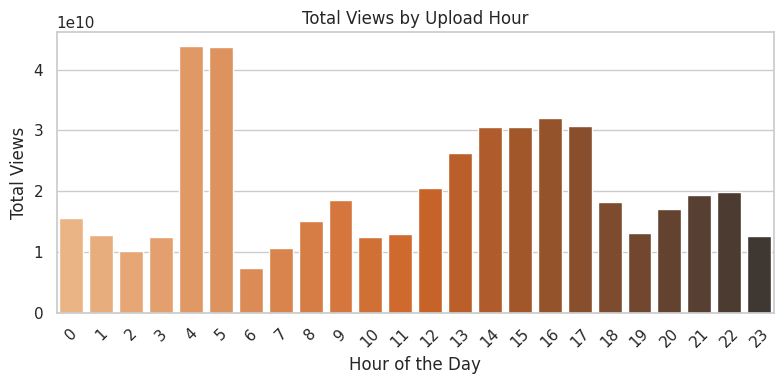

In [44]:
# Extract hour
df_global['publish_hour'] = df_global['publish_time'].dt.hour

# Group by hour and get totals
hour_totals = df_global.groupby('publish_hour')[['views', 'likes', 'dislikes']].sum().reset_index()
hour_totals = hour_totals.sort_values('views', ascending=False)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=hour_totals, x='publish_hour', y='views', palette='Oranges_d')
plt.title('Total Views by Upload Hour')
plt.ylabel('Total Views')
plt.xlabel('Hour of the Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Controversial Videos

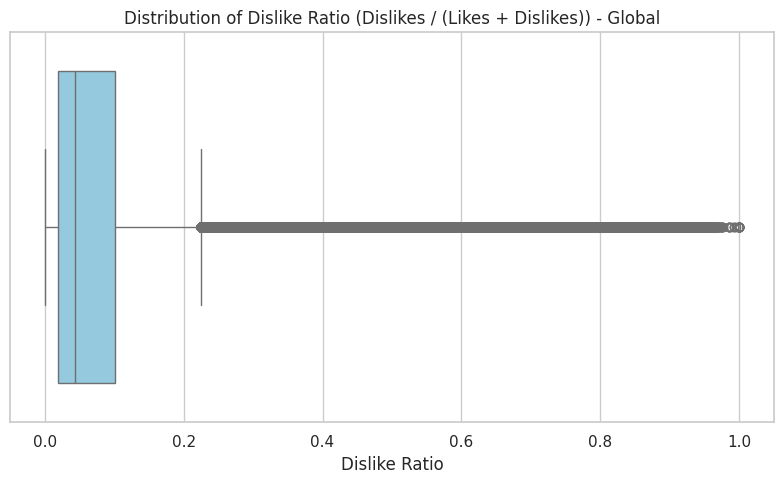

In [45]:
# Calculate dislike ratio
df_global['dislike_ratio'] = df_global['dislikes'] / (df_global['likes'] + df_global['dislikes'])
df_global = df_global.dropna(subset=['dislike_ratio'])  # remove any NaNs (e.g., when both likes and dislikes are 0)

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='dislike_ratio', data=df_global, color='skyblue')
plt.title('Distribution of Dislike Ratio (Dislikes / (Likes + Dislikes)) - Global')
plt.xlabel('Dislike Ratio')
plt.tight_layout()
plt.show()

In [46]:
# Definition
controversial = df_global[df_global['dislike_ratio'] > 0.2].copy()
universally_liked = df_global[df_global['dislike_ratio'] < 0.04].copy()

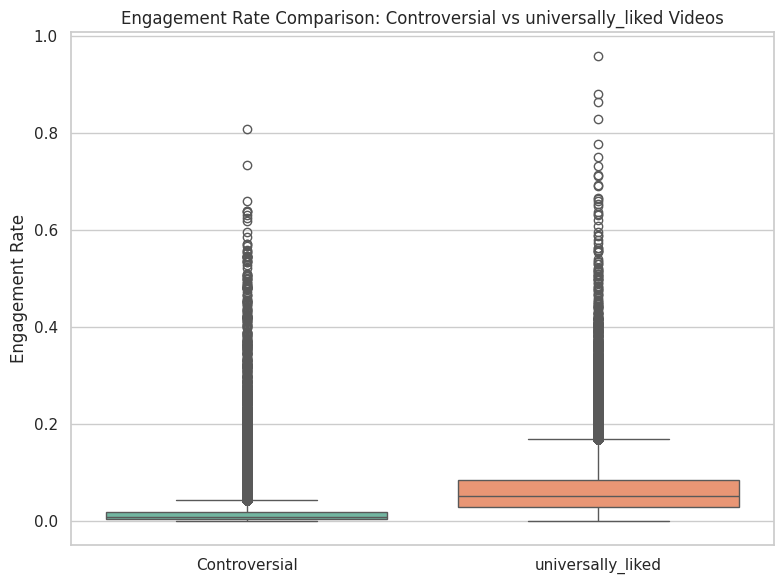

In [47]:
# Engagement rate = (likes + dislikes + comment_count) / views
for df in [controversial, universally_liked]:
    df['engagement_rate'] = (df['likes'] + df['dislikes'] + df['comment_count']) / df['views']

# Combine for plotting
controversial['group'] = 'Controversial'
universally_liked['group'] = 'universally_liked'
compare_df = pd.concat([controversial, universally_liked])

# Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=compare_df, x='group', y='engagement_rate', palette='Set2')
plt.title('Engagement Rate Comparison: Controversial vs universally_liked Videos')
plt.ylabel('Engagement Rate')
plt.xlabel('')
plt.tight_layout()
plt.show()

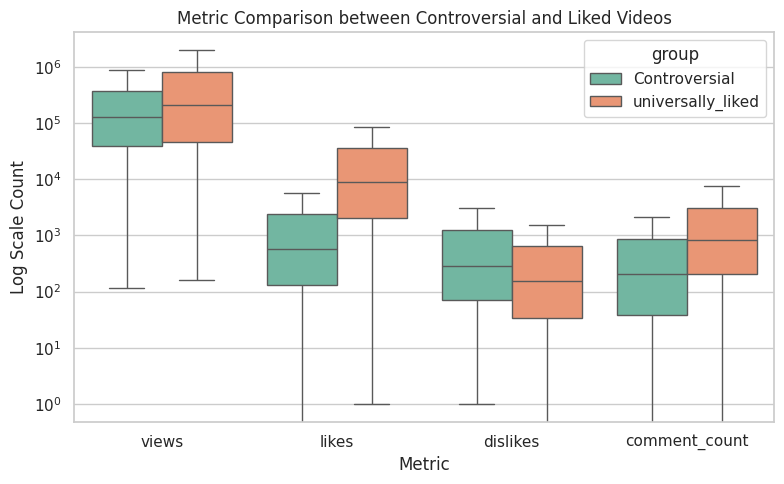

In [48]:
compare_df_metrics = compare_df[['group', 'views', 'likes', 'dislikes', 'comment_count']]

melted_df = compare_df_metrics.melt(id_vars='group', var_name='Metric', value_name='Count')

# Plot
plt.figure(figsize=(8, 5))
sns.boxplot(data=melted_df, x='Metric', y='Count', hue='group', palette='Set2', showfliers=False)
plt.yscale('log')  # Use log scale to handle outliers and scale differences
plt.title('Metric Comparison between Controversial and Liked Videos')
plt.ylabel('Log Scale Count')
plt.tight_layout()
plt.show()

We observe that metrics are generally higher for the universally liked cases, except for dislikes. The inference that can be drawn from this is that people may express their disagreement through dislikes when watching controversial videos. Of course, it's worth noting that this category was defined based on the dislike ratio.

In [49]:
# Mann-Whitney U Test
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(controversial['engagement_rate'], universally_liked['engagement_rate'], alternative='two-sided')
print(f"Mann-Whitney U Test: statistic = {stat:.3f}, p-value = {p:.5f}")

Mann-Whitney U Test: statistic = 897053409.000, p-value = 0.00000


The Mann-Whitney U test with a p-value < 0.00001 confirms that the differences in distributions between the two groups are statistically significant, not due to random chance.

Inference:
People might engage more deeply (watch, like, comment) with content they enjoy or agree with, while they use the dislike button more selectively for expressing disagreement — especially in controversial topics.

### Tags

#### Which tags are most commonly used in trending videos?

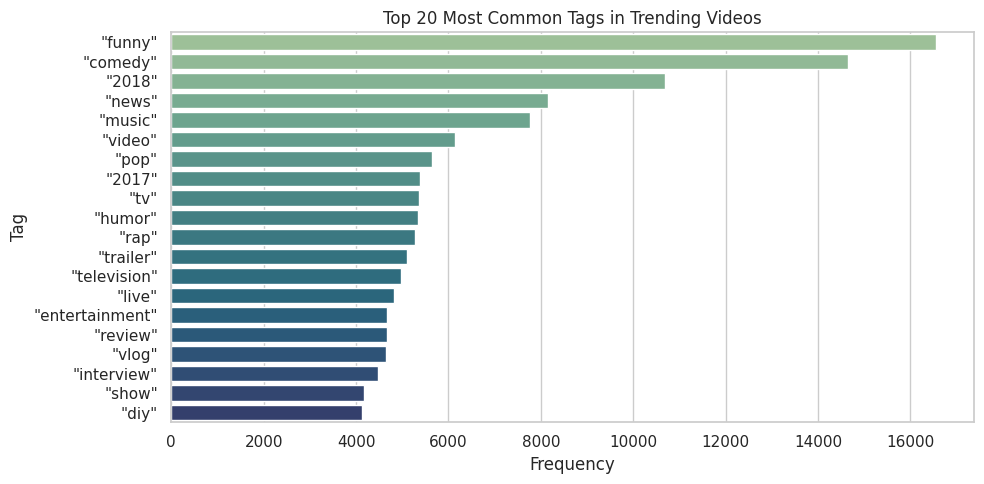

In [50]:
# Drop NaNs and filter out "[none]"
tags_series = df_global['tags'].dropna()
tags_series = tags_series[~tags_series.str.lower().str.contains(r'\[none\]')]

# Split tags by '|' and explode into individual rows
tags_splited = tags_series.str.lower().str.split('|').explode()

# Remove empty or whitespace-only tags
tags_splited = tags_splited[tags_splited.str.strip() != '']

# Count tag occurrences
tag_counts_df = tags_splited.value_counts().head(20).reset_index()
tag_counts_df.columns = ['tag', 'count']

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=tag_counts_df, x='count', y='tag', palette='crest')
plt.title('Top 20 Most Common Tags in Trending Videos')
plt.xlabel('Frequency')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

#### How do video tags influence engagement?

In [51]:
df_global['num_tags'] = df_global['tags'].apply(lambda x: len([tag for tag in x.split('|') if tag.strip() and tag.strip().lower() != '[none]']))
df_global['engagement_ratio'] = (df_global['likes'] + df_global['dislikes'] + df_global['comment_count']) / df_global['views']

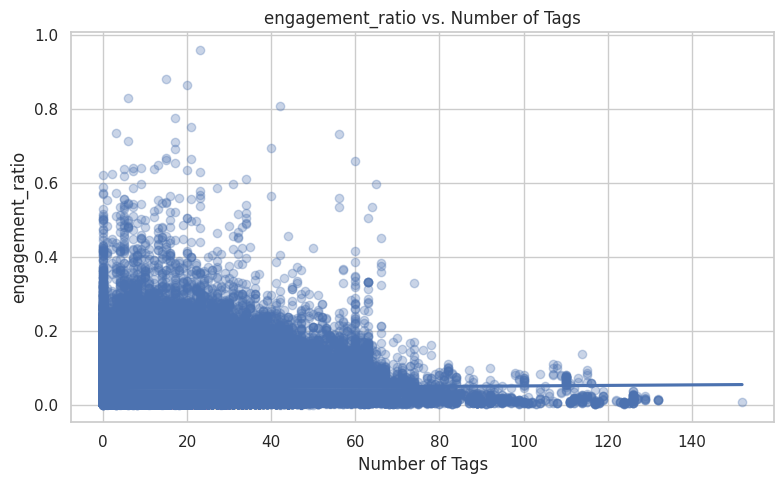

In [52]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df_global, x='num_tags', y='engagement_ratio', scatter_kws={'alpha':0.3})
plt.title('engagement_ratio vs. Number of Tags')
plt.xlabel('Number of Tags')

plt.tight_layout()
plt.show()

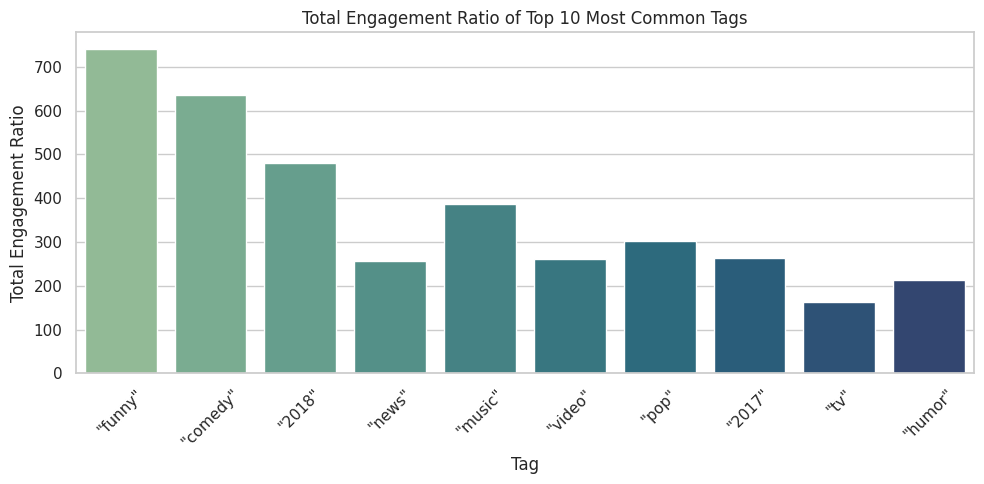

In [53]:
tag_engagement = {}
top_tags = tag_counts_df['tag'].head(10)

for tag in top_tags:
    mask = df_global['tags'].str.lower().str.contains(fr'{tag}', na=False)
    tag_engagement[tag] = df_global.loc[mask, 'engagement_ratio'].sum()

# Plot using seaborn
plt.figure(figsize=(10, 5))
sns.barplot(x=list(tag_engagement.keys()), y=list(tag_engagement.values()), palette="crest")
plt.title("Total Engagement Ratio of Top 10 Most Common Tags")
plt.ylabel("Total Engagement Ratio")
plt.xlabel("Tag")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

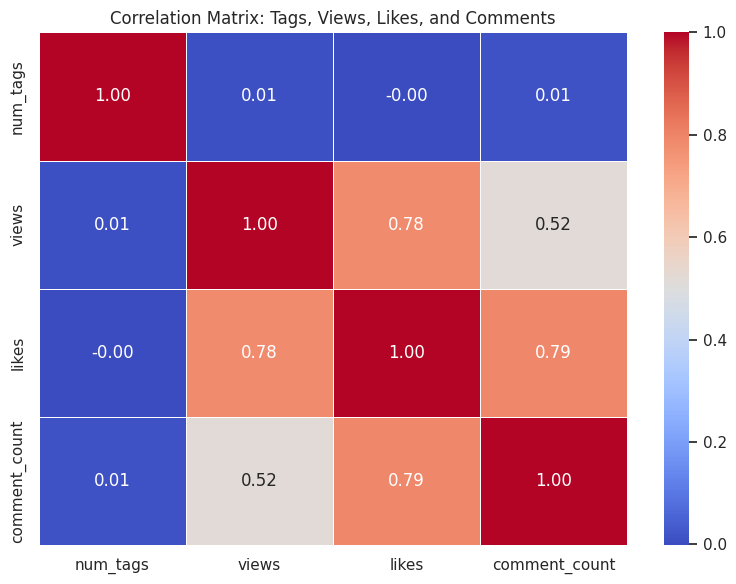

In [54]:
corr_matrix = df_global[['num_tags', 'views', 'likes', 'comment_count']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Tags, Views, Likes, and Comments")
plt.tight_layout()
plt.show()

### Video Title

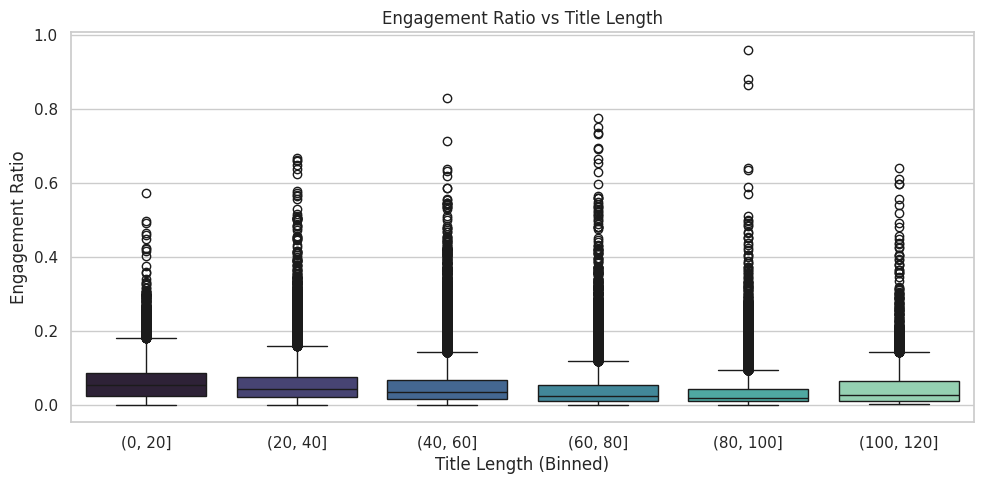

In [55]:
# Add title length column
df_global['title_length'] = df_global['title'].str.len()

# Plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_global, x=pd.cut(df_global['title_length'], bins=[0, 20, 40, 60, 80, 100, 120]),
            y='engagement_ratio', palette='mako')
plt.title("Engagement Ratio vs Title Length")
plt.xlabel("Title Length (Binned)")
plt.ylabel("Engagement Ratio")
plt.tight_layout()
plt.show()

Inference: It seems that short title videos (0 to 20 characters) have more engagement ratio

### Video Title Sentiment

In [56]:
from textblob import TextBlob

# Extract sentiment polarity
df_global['title_sentiment'] = df_global['title'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Categorize sentiment
def categorize_sentiment(p):
    if p > 0.1:
        return 'Positive'
    elif p < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df_global['sentiment_category'] = df_global['title_sentiment'].apply(categorize_sentiment)

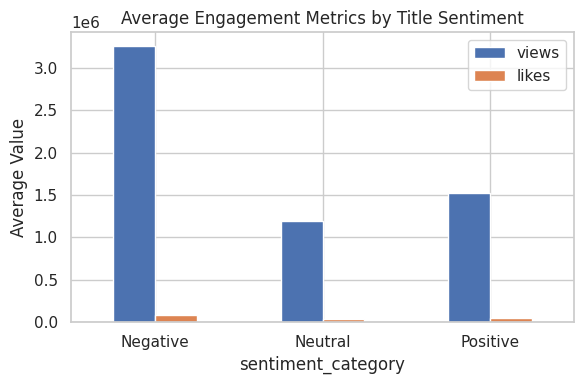

In [57]:
# Aggregate engagement metrics
sentiment_engagement = df_global.groupby('sentiment_category')[['views', 'likes']].mean()

# Plot
sentiment_engagement.plot(kind='bar', figsize=(6, 4))
plt.title("Average Engagement Metrics by Title Sentiment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

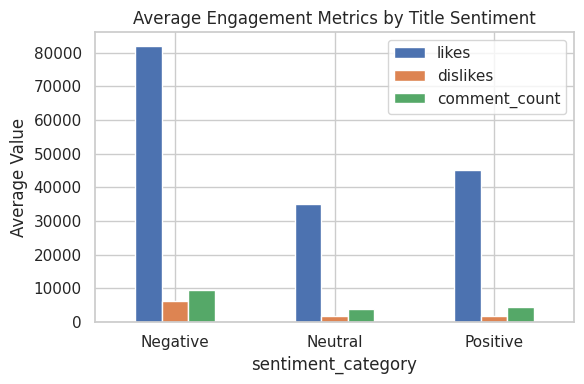

In [58]:
# Aggregate engagement metrics
sentiment_engagement = df_global.groupby('sentiment_category')[['likes', 'dislikes', 'comment_count']].mean()

# Plot
sentiment_engagement.plot(kind='bar', figsize=(6, 4))
plt.title("Average Engagement Metrics by Title Sentiment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

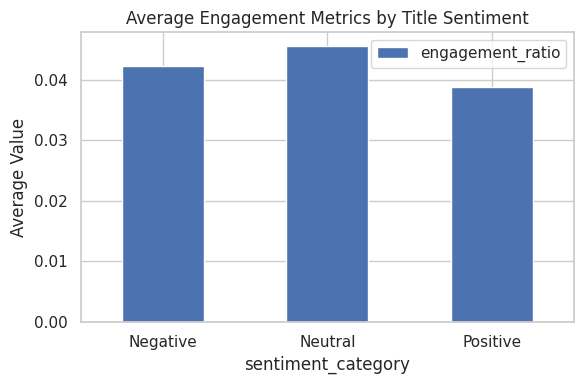

In [59]:
# Aggregate engagement metrics
sentiment_engagement = df_global.groupby('sentiment_category')[['engagement_ratio']].mean()

# Plot
sentiment_engagement.plot(kind='bar', figsize=(6, 4))
plt.title("Average Engagement Metrics by Title Sentiment")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Clickbait-style Titles

In [60]:
clickbait_keywords = [
    'shocking', 'unbelievable', 'must watch', 'you won’t believe', 'amazing', 'epic', 'crazy',
    'insane', 'top', 'secret', 'wow', 'gone wrong', 'emotional', 'never seen before',
    'exposed', 'watch till the end', 'life-changing', 'insane footage', 'what happened next',
    'truth revealed', 'breaking', 'scary', 'warning', 'biggest ever', 'this changes everything',
    'don’t miss', 'unexpected', 'jaw dropping', 'no one talks about', 'can’t believe',
    'ultimate', 'only a genius can', 'guess what', 'you need to see this', 'right now',
    'don’t try this', 'too cute', 'you have to see', 'caught on camera', 'this is why'
]


In [61]:
pattern = '|'.join([fr'\b{word}\b' for word in clickbait_keywords])
df_global['is_clickbait'] = df_global['title'].str.lower().str.contains(pattern, na=False)

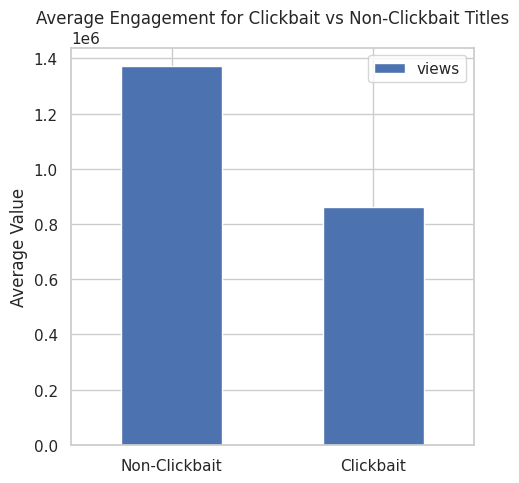

In [62]:
engagement_cmp = df_global.groupby('is_clickbait')[['views']].mean()
engagement_cmp.index = ['Non-Clickbait', 'Clickbait']

engagement_cmp.plot(kind='bar', figsize=(5, 5))
plt.title('Average Engagement for Clickbait vs Non-Clickbait Titles')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


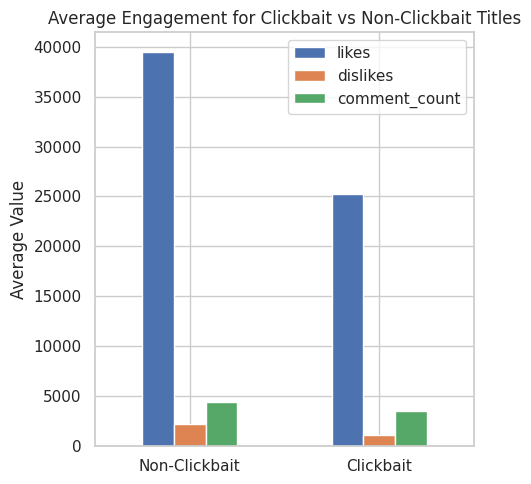

In [63]:
engagement_cmp = df_global.groupby('is_clickbait')[['likes', 'dislikes', 'comment_count']].mean()
engagement_cmp.index = ['Non-Clickbait', 'Clickbait']

engagement_cmp.plot(kind='bar', figsize=(5, 5))
plt.title('Average Engagement for Clickbait vs Non-Clickbait Titles')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Statistical Questions

### Is there a significant association between the day of the week a video is published and its likelihood of trending?

We only have videos that already trended, so:
We know which days are more common among trending videos.
But We don’t know how many total videos were uploaded on those days.
So We can't compute true probabilities (likelihoods) !!!

### Is there a significant difference in viewer engagement (likes-to-views ratio) across different video categories?

In [64]:
# Compute the likes-to-views ratio
df_global['like_view_ratio'] = df_global['likes'] / df_global['views']

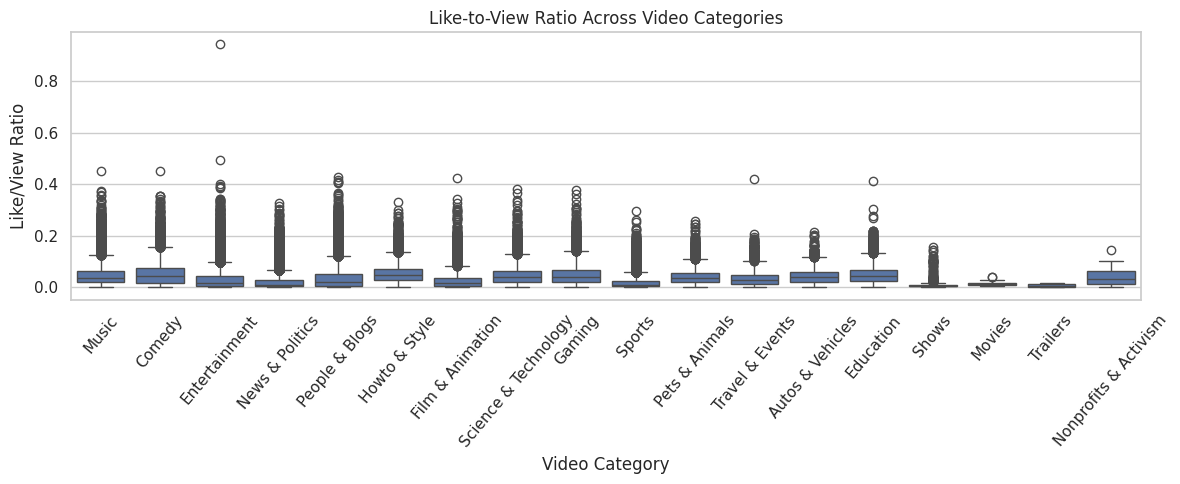

In [65]:
# Boxplot of like/view ratio across categories
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_global, x='category', y='like_view_ratio')
plt.xticks(rotation=50)
plt.title('Like-to-View Ratio Across Video Categories')
plt.ylabel('Like/View Ratio')
plt.xlabel('Video Category')
plt.tight_layout()
plt.show()

In [66]:
from scipy.stats import kruskal

# Prepare data for each category
grouped = df_global.groupby('category')['like_view_ratio'].apply(list)

# Perform Kruskal-Wallis test
stat, p_value = kruskal(*grouped)
print(f"Kruskal-Wallis H-test: statistic = {stat:.4f}, p-value = {p_value:.5f}")

Kruskal-Wallis H-test: statistic = 44479.9468, p-value = 0.00000


The p-value is less than 0.05, reject the null hypothesis— implying a significant difference exists in engagement across categories.
The boxplot helps to see which categories have higher/lower typical engagement.

## Questions Based On Story

All trending videos aren't created equal—some explode, others fizzle. What patterns can we find that explain why certain trending videos perform far better than others?

Since all videos are trending, we define virality using a measurable threshold:
Top 10% in engagement ratio

In [67]:
# Calculate 90th percentile threshold
viral_threshold = df_global['engagement_ratio'].quantile(0.90)

df_global['is_viral'] = df_global['engagement_ratio'] > viral_threshold

print(f"Viral threshold: {viral_threshold}")
print(df_global['is_viral'].value_counts())

Viral threshold: 0.10200935966734673
is_viral
False    318711
True      35413
Name: count, dtype: int64


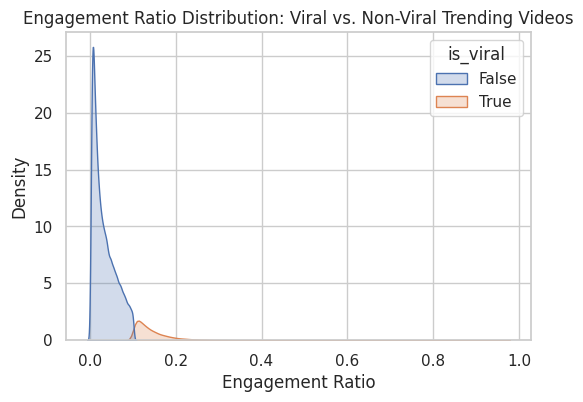

In [68]:
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_global, x='engagement_ratio', hue='is_viral', fill=True)
plt.title('Engagement Ratio Distribution: Viral vs. Non-Viral Trending Videos')
plt.xlabel('Engagement Ratio')
plt.ylabel('Density')
plt.grid(True)
plt.show()

### How does the title sentiment category (positive, neutral, negative) differ between viral and non-viral trending videos?

<Figure size 600x400 with 0 Axes>

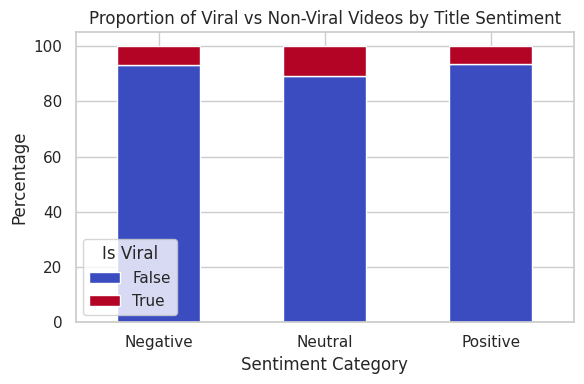

In [69]:
# Crosstab of sentiment vs virality
sentiment_crosstab = pd.crosstab(df_global['sentiment_category'], df_global['is_viral'], normalize='index') * 100

# Plotting
plt.figure(figsize=(6, 4))
sentiment_crosstab.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(6, 4))
plt.title("Proportion of Viral vs Non-Viral Videos by Title Sentiment")
plt.ylabel("Percentage")
plt.xlabel("Sentiment Category")
plt.legend(title="Is Viral")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [70]:
# Chi-square test
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_global['sentiment_category'], df_global['is_viral'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square test result:")
print(f"Chi² = {chi2:.2f}, p-value = {p:.4f}")
if p < 0.05:
    print("Statistically significant difference in sentiment distribution between viral and non-viral videos.")
else:
    print("No significant difference in sentiment distribution.")

Chi-square test result:
Chi² = 1202.91, p-value = 0.0000
Statistically significant difference in sentiment distribution between viral and non-viral videos.


### What is the effect of number of tags (num_tags) on virality? Is more always better?

* Visualize the distribution of num_tags for viral vs. non-viral videos:

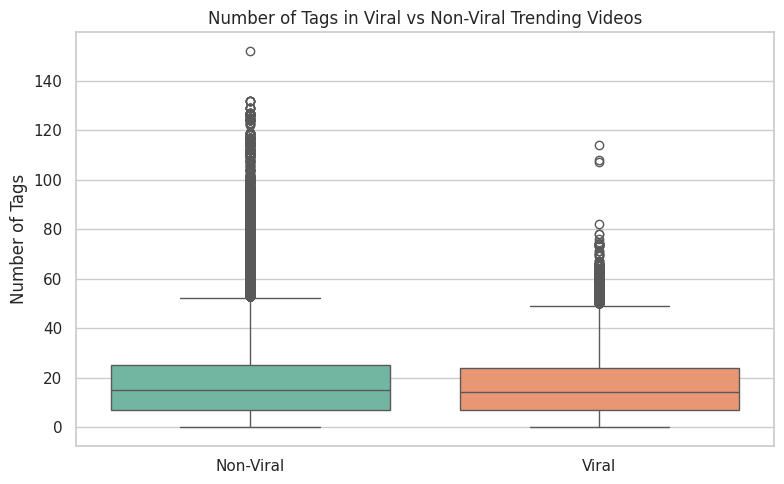

In [71]:
# Split into viral and non-viral
viral_tags = df_global[df_global['is_viral']]['num_tags']
non_viral_tags = df_global[~df_global['is_viral']]['num_tags']

# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_global, x='is_viral', y='num_tags', palette='Set2')
plt.xticks([0, 1], ['Non-Viral', 'Viral'])
plt.title("Number of Tags in Viral vs Non-Viral Trending Videos")
plt.xlabel("")
plt.ylabel("Number of Tags")
plt.tight_layout()
plt.show()

In [72]:
# Mann-Whitney U Test
stat, p = mannwhitneyu(viral_tags, non_viral_tags, alternative='two-sided')

print(f"Mann-Whitney U Test: U = {stat:.0f}, p-value = {p:.5f}")
if p < 0.05:
    print("Significant difference in number of tags between viral and non-viral videos.")
else:
    print("No significant difference in number of tags.")

Mann-Whitney U Test: U = 5509364342, p-value = 0.00000
Significant difference in number of tags between viral and non-viral videos.


There's strong statistical evidence that the distribution of num_tags is not the same between viral and non-viral trending vid

### Does publish hour matter? Are viral videos posted at specific times of day?

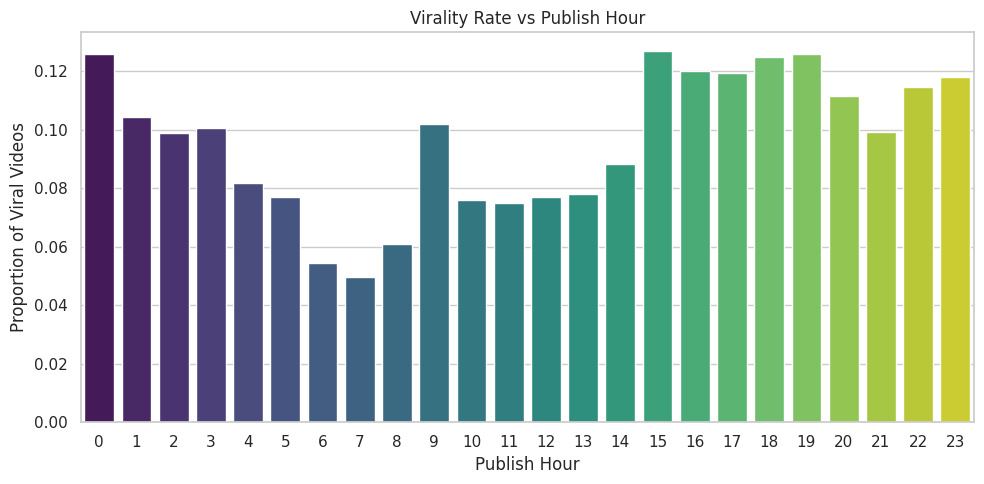

In [73]:
# Set plot style
sns.set(style="whitegrid")

# Q11: Publish hour vs virality
virality_by_hour = df_global.groupby('publish_hour')['is_viral'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=virality_by_hour.index, y=virality_by_hour.values, palette='viridis')
plt.title('Virality Rate vs Publish Hour')
plt.xlabel('Publish Hour')
plt.ylabel('Proportion of Viral Videos')
plt.tight_layout()
plt.show()

### Do clickbait-style titles help more in some categories than others?

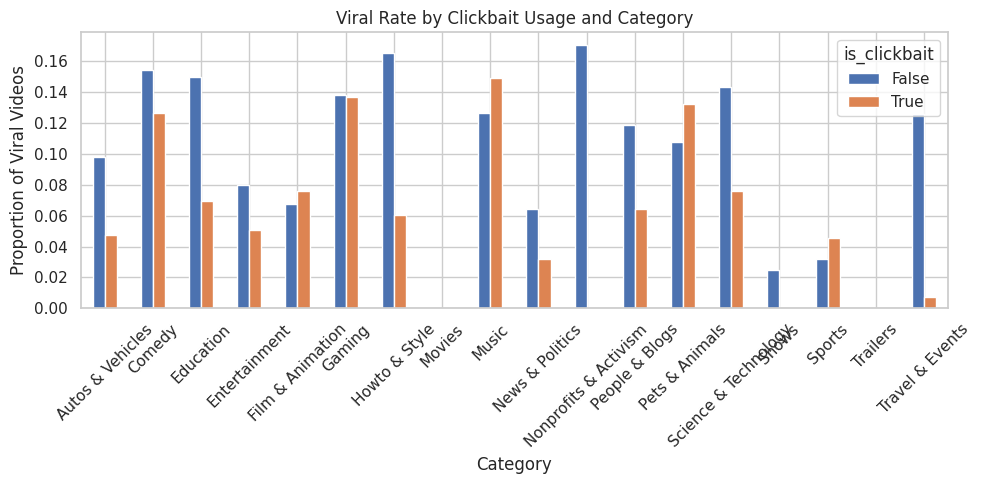

In [74]:
# Q12: Clickbait and category
clickbait_by_cat = df_global.groupby(['category', 'is_clickbait'])['is_viral'].mean().unstack()
clickbait_by_cat.plot(kind='bar', figsize=(10, 5))
plt.title('Viral Rate by Clickbait Usage and Category')
plt.ylabel('Proportion of Viral Videos')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [75]:
# Loop through each category
results = {}
for cat in df_global['category'].unique():
    subset = df_global[df_global['category'] == cat]
    contingency = pd.crosstab(subset['is_clickbait'], subset['is_viral'])
    if contingency.shape == (2, 2):  # Ensure it's valid
        chi2, p, _, _ = chi2_contingency(contingency)
        results[cat] = p

# Show significant categories
significant = {k: v for k, v in results.items() if v < 0.05}
print("Categories where clickbait significantly affects virality:")
for cat, pval in significant.items():
    print(f"{cat}: p-value = {pval:.5f}")

Categories where clickbait significantly affects virality:
Entertainment: p-value = 0.00000
News & Politics: p-value = 0.00451
People & Blogs: p-value = 0.00002
Howto & Style: p-value = 0.00000
Science & Technology: p-value = 0.00427
Travel & Events: p-value = 0.00006
Education: p-value = 0.00216


Significance (small p-value) only tells us there's a statistical association between clickbait and virality, not how it affects it.

When we visualize the bar plots (clickbait_by_cat), we notice that in many categories, clickbait videos are actually less likely to go viral.

Which channels appear most frequently among viral trending videos? Do they post
more often or just better content?

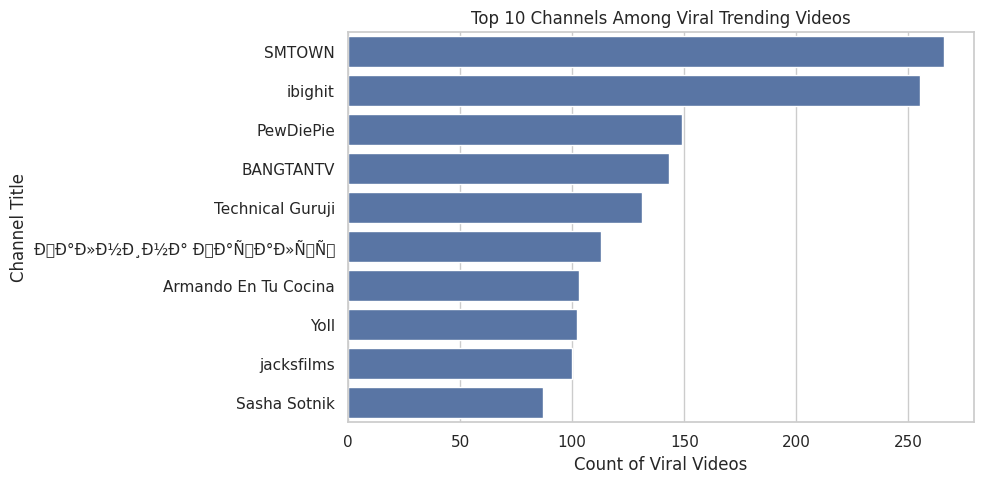

In [76]:
# Q13: Top channels in viral videos
top_viral_channels = df_global[df_global['is_viral']].channel_title.value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_viral_channels.values, y=top_viral_channels.index)
plt.title('Top 10 Channels Among Viral Trending Videos')
plt.xlabel('Count of Viral Videos')
plt.ylabel('Channel Title')
plt.tight_layout()
plt.show()

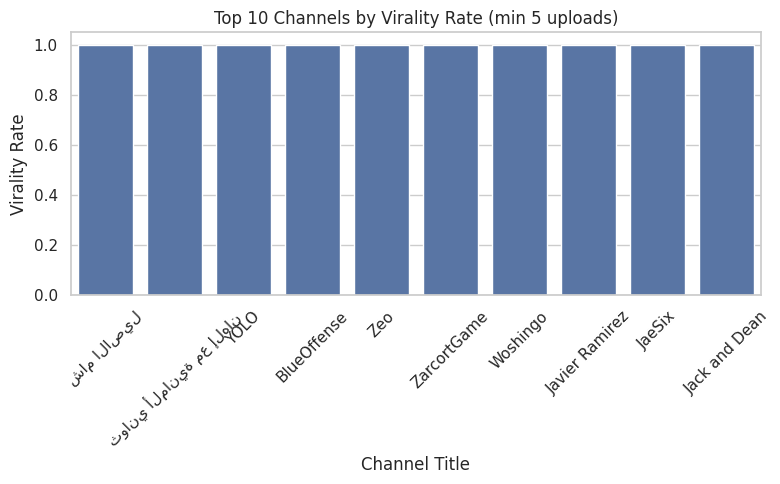

In [77]:
channel_stats = df_global.groupby('channel_title').agg(
    total_videos=('video_id', 'count'),
    viral_videos=('is_viral', 'sum')
).reset_index()

# Calculate virality rate
channel_stats['virality_rate'] = channel_stats['viral_videos'] / channel_stats['total_videos']

# Top 10 channels by virality rate (with at least 5 videos to be fair)
top_viral_channels = channel_stats[channel_stats['total_videos'] >= 5].sort_values(
    by='virality_rate', ascending=False
).head(10)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=top_viral_channels, x='channel_title', y='virality_rate')
plt.xticks(rotation=45)
plt.title("Top 10 Channels by Virality Rate (min 5 uploads)")
plt.ylabel("Virality Rate")
plt.xlabel("Channel Title")
plt.tight_layout()
plt.show()

### Are there cross-country differences in what goes viral?

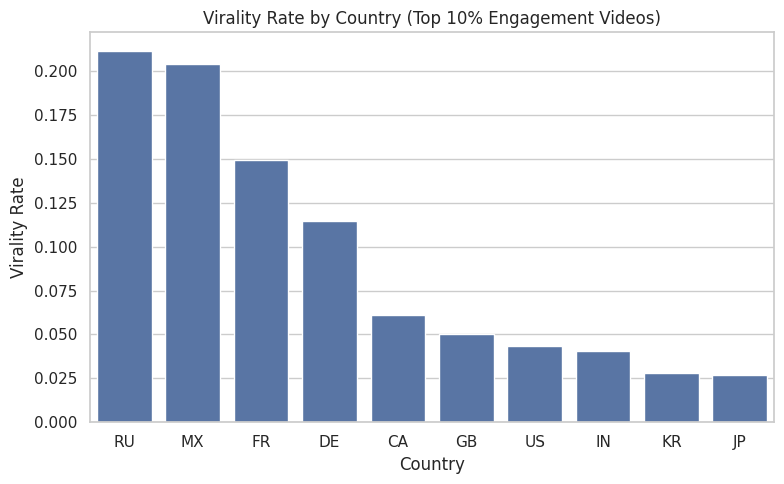

In [78]:
# Group by country
country_virality = df_global.groupby('country').agg(
    total_videos=('video_id', 'count'),
    viral_videos=('is_viral', 'sum')
).reset_index()

# Calculate virality rate
country_virality['virality_rate'] = country_virality['viral_videos'] / country_virality['total_videos']

# Sort and visualize
country_virality = country_virality.sort_values(by='virality_rate', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=country_virality, x='country', y='virality_rate')
plt.title("Virality Rate by Country (Top 10% Engagement Videos)")
plt.ylabel("Virality Rate")
plt.xlabel("Country")
plt.tight_layout()
plt.show()